<a href="https://colab.research.google.com/github/f247805/thesis/blob/main/XML_Roberta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd, json

data = []
with open("/content/drive/MyDrive/urdu_absa_cleaned.json", "r", encoding="utf-8") as f:
    for line in f:
        entry = json.loads(line)
        for label in entry["labels"]:
            data.append({
                "text": entry["text"],
                "aspect": label["aspect"],
                "polarity": label["polarity"]
            })

df = pd.DataFrame(data)
print("✅ Flattened dataset shape:", df.shape)
df.head()


✅ Flattened dataset shape: (30808, 3)


,text,aspect,polarity
0,مینو بہت اچہا لگ رہا تہا ، لیکن کہانا سب سے بڑ...,مینو,positive
1,مینو بہت اچہا لگ رہا تہا ، لیکن کہانا سب سے بڑ...,کہانا,negative
2,پیشہ وسط سے اعلی سطح پر 100 اسپیکر کے لئے زبرد...,آواز,positive
3,خدمت دوستانہ تہی ، لیکن بہت زیادہ توجہ نہیں تہ...,خدمت,positive
4,خدمت دوستانہ تہی ، لیکن بہت زیادہ توجہ نہیں تہ...,رات کا کہانا,neutral


In [ ]:
import json

path = "/content/absa_urdu_from16000 (1).json"

with open(path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i < 3:  # just preview 3 lines
            print(line.strip())


{"text": "مینو بہت اچھا لگ رہا تھا ، لیکن کھانا سب سے بڑی مایوسی تھی جو میں نے ابھی تک کی تھی!", "labels": [{"aspect": "مینو", "polarity": "positive"}, {"aspect": "کھانا", "polarity": "negative"}]}
{"text": "پیشہ: - وسط سے اعلی سطح پر $ 100 اسپیکر کے لئے زبردست آواز۔", "labels": [{"aspect": "آواز", "polarity": "positive"}]}
{"text": "خدمت دوستانہ تھی ، لیکن بہت زیادہ توجہ نہیں تھی ، رات کے کھانے کے بعد ہماری پلیٹوں کو صاف کرنے کے لئے 30 منٹ ، اور ہماری جانچ پڑتال کرنے میں مزید 20 منٹ لگے۔", "labels": [{"aspect": "خدمت", "polarity": "positive"}, {"aspect": "رات کا کھانا", "polarity": "neutral"}, {"aspect": "پلیٹیں", "polarity": "neutral"}]}


In [ ]:
import json, re

input_file = "/content/absa_urdu_from16000 (1).json"
output_file = "/content/drive/MyDrive/urdu_absa_cleaned.json"

def normalize_urdu(text):
    # Urdu normalization rules
    text = text.replace("ي", "ی").replace("ك", "ک").replace("ھ", "ہ").replace("ۀ", "ہ").replace("ہٗ", "ہ")
    text = re.sub(r"[ـًٌٍَُِّْٰٖٕٗ]", "", text)  # remove diacritics
    text = re.sub(r"[^\u0600-\u06FF0-9\s.,!?]", "", text)  # keep Urdu + punctuation
    return re.sub(r"\s+", " ", text).strip()

cleaned_data = []
bad_lines = 0

with open(input_file, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, start=1):
        try:
            entry = json.loads(line.strip())
            if not isinstance(entry.get("labels"), list) or len(entry["labels"]) == 0:
                bad_lines += 1
                continue

            entry["text"] = normalize_urdu(entry["text"])
            new_labels = []
            for label in entry["labels"]:
                if "aspect" in label and "polarity" in label:
                    aspect = normalize_urdu(label["aspect"])
                    polarity = label["polarity"].strip().lower()
                    new_labels.append({"aspect": aspect, "polarity": polarity})

            if len(new_labels) == 0:
                bad_lines += 1
                continue

            entry["labels"] = new_labels
            cleaned_data.append(entry)

        except json.JSONDecodeError:
            bad_lines += 1

# Save clean file
with open(output_file, "w", encoding="utf-8") as f:
    for e in cleaned_data:
        f.write(json.dumps(e, ensure_ascii=False) + "\n")

print("✅ Urdu ABSA cleaned dataset saved:", output_file)
print("✅ Total valid entries:", len(cleaned_data))
print("⚠️ Skipped bad lines:", bad_lines)


✅ Urdu ABSA cleaned dataset saved: /content/drive/MyDrive/urdu_absa_cleaned.json
✅ Total valid entries: 16125
⚠️ Skipped bad lines: 0


In [3]:
import pandas as pd, json

data = []
with open("/content/drive/MyDrive/urdu_absa_cleaned.json", "r", encoding="utf-8") as f:
    for line in f:
        entry = json.loads(line)
        for label in entry["labels"]:
            data.append({
                "text": entry["text"],
                "aspect": label["aspect"],
                "polarity": label["polarity"]
            })

df = pd.DataFrame(data)
print("✅ Flattened dataset shape:", df.shape)
df.head()


✅ Flattened dataset shape: (30808, 3)


,text,aspect,polarity
0,مینو بہت اچہا لگ رہا تہا ، لیکن کہانا سب سے بڑ...,مینو,positive
1,مینو بہت اچہا لگ رہا تہا ، لیکن کہانا سب سے بڑ...,کہانا,negative
2,پیشہ وسط سے اعلی سطح پر 100 اسپیکر کے لئے زبرد...,آواز,positive
3,خدمت دوستانہ تہی ، لیکن بہت زیادہ توجہ نہیں تہ...,خدمت,positive
4,خدمت دوستانہ تہی ، لیکن بہت زیادہ توجہ نہیں تہ...,رات کا کہانا,neutral


In [ ]:
df.to_csv("/content/drive/MyDrive/urdu_absa_flat.csv", index=False, encoding="utf-8")
print("✅ Saved Urdu ABSA CSV for inspection")


✅ Saved Urdu ABSA CSV for inspection


In [ ]:
print(df["polarity"].value_counts())


polarity
positive    14451
negative     9261
neutral      7096
Name: count, dtype: int64


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2645089380.py:82: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


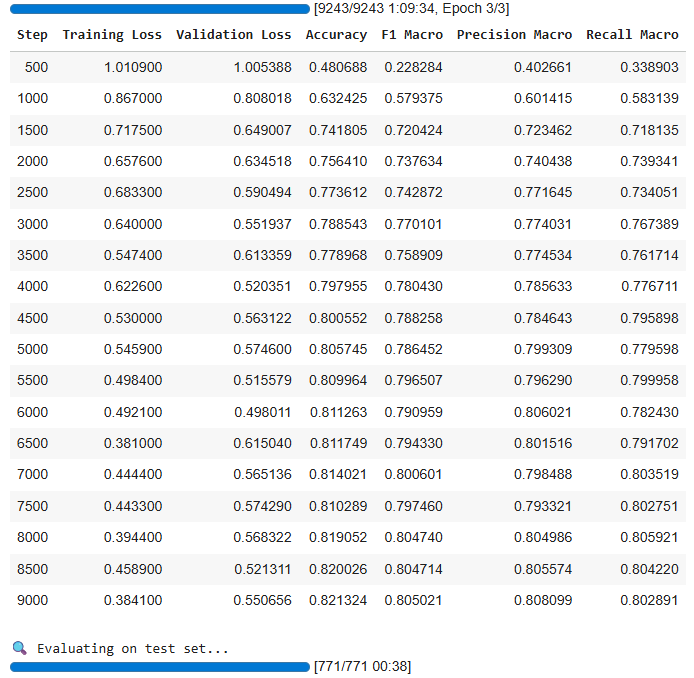


eval_loss: 0.4980
eval_accuracy: 0.806
eval_f1_macro: 0.7910
eval_precision_macro: 0.8060
eval_recall_macro: 0.7824
eval_runtime: 39.0917
eval_samples_per_second: 157.6290
eval_steps_per_second: 19.7230
epoch: 3.0000
✅ Training & evaluation complete! Model saved to Drive.


In [16]:

import pandas as pd
import torch # Import the torch library
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import evaluate
from sklearn.model_selection import train_test_split
Wanadb= "True"
# 4️⃣ Prepare inputs and labels
df["input"] = df["text"] + " [SEP] " + df["aspect"]
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}
df["label"] = df["polarity"].map(label2id)

# 5️⃣ Train/test split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["input"].tolist(), df["label"].tolist(), test_size=0.2, random_state=42
)

# 6️⃣ Tokenization
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

# 7️⃣ PyTorch Dataset class
class ABSADataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = ABSADataset(train_encodings, train_labels)
test_dataset = ABSADataset(test_encodings, test_labels)

# 8️⃣ Load model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=3, id2label=id2label, label2id=label2id
)

# 9️⃣ Define metrics
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")
precision = evaluate.load("precision")
recall = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    results = {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
        "precision_macro": precision.compute(predictions=preds, references=labels, average="macro")["precision"],
        "recall_macro": recall.compute(predictions=preds, references=labels, average="macro")["recall"]
    }
    return results

# 🔟 Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps", # Changed from evaluation_strategy
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
    report_to=["tensorboard"] # Explicitly disable Weights & Biases
)

# 1️⃣1️⃣ Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# 1️⃣2️⃣ Train
trainer.train()

# 1️⃣3️⃣ Evaluate on test set
print("\n🔍 Evaluating on test set...")
eval_results = trainer.evaluate(test_dataset)
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

# 1️⃣4️⃣ Save trained model
trainer.save_model("/content/drive/MyDrive/xlm_roberta_absa_urduaaepochs")

print("✅ Training & evaluation complete! Model saved to Drive.")

In [ ]:
import pandas as pd
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Assuming your model has been trained and is in the trainer object
# If you want to test right after training, the trainer already has the model

# OPTION 1: Test using the already trained model in trainer (SIMPLEST)
print("🧪 TESTING USING TRAINER'S MODEL...")

# Get predictions on test set
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# Calculate metrics
print("\n📊 DETAILED TEST RESULTS:")
print("=" * 50)
print(f"Accuracy: {accuracy_score(true_labels, pred_labels):.4f}")
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels,
                          target_names=["negative", "neutral", "positive"]))

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# OPTION 2: Manual testing on specific samples
print("\n🔍 MANUAL TESTING ON SAMPLE TEXTS:")
print("=" * 50)

# Select some samples from test set
sample_indices = [0, 1, 2, 3, 4]  # First 5 test samples
for idx in sample_indices:
    if idx < len(test_texts):
        # Get the sample
        text = test_texts[idx]
        true_label = test_labels[idx]
        true_label_name = id2label[true_label]

        # Prepare input
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)

        # Move to device and predict
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            predictions = torch.softmax(outputs.logits, dim=-1)
            pred_label = torch.argmax(predictions, dim=-1).item()
            pred_label_name = id2label[pred_label]

        # Extract text and aspect
        if " [SEP] " in text:
            original_text, aspect = text.split(" [SEP] ")
        else:
            original_text, aspect = text, "N/A"

        print(f"\nSample {idx + 1}:")
        print(f"Text: {original_text}")
        print(f"Aspect: {aspect}")
        print(f"True Sentiment: {true_label_name} ({true_label})")
        print(f"Predicted Sentiment: {pred_label_name} ({pred_label})")
        print(f"Confidence: {predictions[0][pred_label]:.4f}")
        print(f"Status: {'✅ CORRECT' if pred_label == true_label else '❌ WRONG'}")
        print("-" * 40)

# OPTION 3: Test on custom new sentences
print("\n🎯 TEST ON CUSTOM INPUTS:")
print("=" * 50)

custom_samples = [
    {"text": "یہ فون کا کیمیرا بہت اچھا ہے", "aspect": "کیمیرا"},
    {"text": "بجٹ مناسب نہیں ہے", "aspect": "قیمت"},
    {"text": "پرافراد چھوٹا ہے", "aspect": "سائز"},
    {"text": "کارکردگی اوسط ہے", "aspect": "کارکردگی"},
    {"text": "ڈیزائن شاندار ہے", "aspect": "ڈیزائن"},
]

for i, sample in enumerate(custom_samples):
    input_text = f"{sample['text']} [SEP] {sample['aspect']}"

    # Tokenize
    inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.softmax(outputs.logits, dim=-1)
        pred_label = torch.argmax(predictions, dim=-1).item()
        pred_label_name = id2label[pred_label]

    # Get confidence scores
    confidence_scores = {id2label[i]: float(predictions[0][i]) for i in range(3)}

    print(f"\nCustom Sample {i + 1}:")
    print(f"Text: {sample['text']}")
    print(f"Aspect: {sample['aspect']}")
    print(f"Predicted Sentiment: {pred_label_name}")
    print(f"Confidence Scores:")
    for sentiment, score in confidence_scores.items():
        print(f"  {sentiment}: {score:.4f}")
    print("-" * 40)

# Save predictions to CSV
print("\n💾 SAVING PREDICTIONS TO CSV...")
results_df = pd.DataFrame({
    "text": [t.split(" [SEP] ")[0] if " [SEP] " in t else t for t in test_texts],
    "aspect": [t.split(" [SEP] ")[1] if " [SEP] " in t else "" for t in test_texts],
    "true_label": [id2label[l] for l in true_labels],
    "predicted_label": [id2label[l] for l in pred_labels],
    "is_correct": true_labels == pred_labels
})

# Add confidence scores for each class
confidences = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
results_df["confidence_negative"] = confidences[:, 0]
results_df["confidence_neutral"] = confidences[:, 1]
results_df["confidence_positive"] = confidences[:, 2]

# Save to CSV
results_df.to_csv("test_predictions.csv", index=False)
print(f"✅ Predictions saved to 'test_predictions.csv' ({len(results_df)} samples)")

# Show error analysis
print("\n🔎 ERROR ANALYSIS:")
print("=" * 50)
incorrect_samples = results_df[~results_df["is_correct"]]
print(f"Total incorrect predictions: {len(incorrect_samples)}/{len(results_df)} ({len(incorrect_samples)/len(results_df)*100:.2f}%)")

if len(incorrect_samples) > 0:
    print("\nFirst 5 incorrect predictions:")
    for idx, row in incorrect_samples.head().iterrows():
        print(f"\nText: {row['text']}")
        print(f"Aspect: {row['aspect']}")
        print(f"True: {row['true_label']}, Predicted: {row['predicted_label']}")
        print(f"Confidences - Negative: {row['confidence_negative']:.3f}, "
              f"Neutral: {row['confidence_neutral']:.3f}, "
              f"Positive: {row['confidence_positive']:.3f}")
        print("-" * 40)

print("\n✅ Testing complete!")

EXplainability
# New Section

In [ ]:
# LOAD YOUR MODEL WITH SAFETENSORS
print("🚀 LOADING YOUR MODEL WITH SAFETENSORS...")

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import os

model_path = "/content/drive/MyDrive/xlm_roberta_absa_urdu"

try:
    # Method 1: Try direct loading (should work with safetensors)
    print("📥 Loading tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(model_path)

    print("📥 Loading model...")
    model = AutoModelForSequenceClassification.from_pretrained(model_path)

    model.eval()
    print("✅ Model loaded successfully!")
    print(f"🤖 Model type: {type(model)}")
    print(f"📍 Device: {next(model.parameters()).device}")

except Exception as e:
    print(f"❌ Error: {e}")

    # Method 2: Try with explicit trust_remote_code
    try:
        print("\n🔄 Trying with trust_remote_code...")
        tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
        model = AutoModelForSequenceClassification.from_pretrained(model_path, trust_remote_code=True)
        model.eval()
        print("✅ Success with trust_remote_code!")

    except Exception as e2:
        print(f"❌ Still failed: {e2}")

        # Method 3: Manual loading with safetensors
        try:
            print("\n🔄 Manual loading with safetensors...")
            from transformers import XLMRobertaConfig, XLMRobertaForSequenceClassification, XLMRobertaTokenizer
            from safetensors.torch import load_file

            # Load config
            config = XLMRobertaConfig.from_pretrained(model_path)

            # Load tokenizer
            tokenizer = XLMRobertaTokenizer.from_pretrained(model_path)

            # Create model
            model = XLMRobertaForSequenceClassification.from_pretrained(
                "xlm-roberta-base",
                config=config,
                ignore_mismatched_sizes=True
            )

            # Load weights from safetensors
            safetensors_path = os.path.join(model_path, "model.safetensors")
            if os.path.exists(safetensors_path):
                state_dict = load_file(safetensors_path)
                model.load_state_dict(state_dict, strict=False)
                print("✅ Success with manual safetensors loading!")
            else:
                print("❌ safetensors file not found")

        except Exception as e3:
            print(f"❌ All methods failed: {e3}")
            raise

print("\n🎉 MODEL LOADED SUCCESSFULLY!")
print("Ready for LIME analysis!")

🚀 LOADING YOUR MODEL WITH SAFETENSORS...
📥 Loading tokenizer...
❌ Error: 'dict' object has no attribute 'model_type'

🔄 Trying with trust_remote_code...
❌ Still failed: 'dict' object has no attribute 'model_type'

🔄 Manual loading with safetensors...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

In [ ]:
import torch.nn.functional as F

def predict_sentiment(text, aspect):
    sep_token = tokenizer.sep_token if tokenizer.sep_token else "</s>"
    input_text = text + " " + sep_token + " " + aspect

    inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    labels = ["negative", "neutral", "positive"]
    pred_label = labels[probs.argmax()]
    return pred_label, dict(zip(labels, probs))


In [ ]:
import re

# simple aspect extraction (can be replaced by ML/NLP-based extractor)
possible_aspects = ["بیٹری", "کارکردگی", "قیمت", "اسکرین", "ڈیزائن", "کھانا"]

def find_aspects(text):
    found = [a for a in possible_aspects if re.search(a, text)]
    return found

def predict_for_all_aspects(text):
    aspects = find_aspects(text)
    results = {}
    for asp in aspects:
        pred, scores = predict_sentiment(text, asp)
        results[asp] = pred
    return results

# Run
text = "قیمت پہلے زیادہ تھی مگر اب معقول ہو گئی ہے"

results = predict_for_all_aspects(text)

print("🔍 Aspect Sentiments:")
for asp, sentiment in results.items():
    print(f"{asp}: {sentiment}")

🔍 Aspect Sentiments:
قیمت: negative


In [ ]:
!pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e8532ba3bcfaa268929f606adc49dbb56779efad1483ff50ee233e530d8ad8b4
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import lime
import lime.lime_text
import numpy as np
import torch
import torch.nn.functional as F
# Assume 'model', 'tokenizer', and 'possible_aspects' are already defined and loaded.
# from transformers import AutoTokenizer, XLMRobertaForSequenceClassification

In [ ]:
def lime_predict_proba(texts):
    """
    A prediction function compatible with LIME's TextExplainer.
    Takes a list of raw strings, tokenizes them with the specific aspect,
    and returns a numpy array of probabilities (samples x classes).
    """
    # NOTE: LIME expects the prediction function to only take the text samples.
    # We need to *hardcode* the target aspect for this specific explanation.
    # LIME generates perturbed samples for this fixed aspect.

    # ⚠️ IMPORTANT: Set the specific aspect you want to explain here
    target_aspect = "بیٹری" # Example aspect: "battery"

    # Define the class labels and their order
    labels = ["negative", "neutral", "positive"]

    all_probs = []
    for text in texts:
        sep_token = tokenizer.sep_token if tokenizer.sep_token else "</s>"
        # Concatenate text and aspect, just like in your original function
        input_text = text + " " + sep_token + " " + target_aspect

        inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=128)
        # Move inputs to the same device as the model (e.g., 'cuda' or 'cpu')
        device = model.device
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            # Apply softmax and get probabilities
            probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
            all_probs.append(probs)

    # Return as a NumPy array of shape (number_of_samples, number_of_classes)
    return np.array(all_probs)

In [ ]:


# 2. Load your model and tokenizer (from your provided code)
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
import numpy as np # Make sure numpy is imported for LIME's internal operations


# 3. Define your LIME-compatible prediction function (as provided before)
def lime_predictor(texts, aspect_term, tokenizer, model):
    sep_token = tokenizer.sep_token if tokenizer.sep_token else "</s>"
    input_texts = [text + " " + sep_token + " " + aspect_term for text in texts]

    inputs = tokenizer(
        input_texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move tensors to the same device as the model (e.g., 'cuda' or 'cpu')
    device = model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()
    return probs

# 4. Define class names for LIME
class_names = ["negative", "neutral", "positive"]

# 5. Initialize LimeTextExplainer
from lime.lime_text import LimeTextExplainer
explainer = LimeTextExplainer(
    class_names=class_names,
    split_expression=' ', # Important for Urdu, treats spaces as delimiters
    random_state=42
)
# 6. Your example text and aspects
text_to_explain = "ریستوراں کا کھانا بہت ہی لذیذ تھا لیکن سروس اچھی نہیں تھی۔"
aspect_food = "کھانا"  # Food
aspect_service = "سروس" # Service

# ----------------------------------------------------------------------
# 1. Explanation for ASPECT 1: "کھانا" (Food)
# ----------------------------------------------------------------------
print(f"--- Explaining Sentiment for Aspect: '{aspect_food}' ---")

explanation_food = explainer.explain_instance(
    text_to_explain,
    classifier_fn=lambda x: lime_predictor(x, aspect_food, tokenizer, model),
    num_features=4,
    num_samples=500,
    # KEY CHANGE: Target the indices for all three classes (negative=0, neutral=1, positive=2)
    top_labels=3
)

# Set the visualization to display explanations for all available classes (up to 3)
explanation_food.show_in_notebook(text=True, labels=(0, 1, 2))


# ----------------------------------------------------------------------
# 2. Explanation for ASPECT 2: "سروس" (Service)
# ----------------------------------------------------------------------
print("\n" + "=" * 50 + "\n")
print(f"--- Explaining Sentiment for Aspect: '{aspect_service}' ---")

explanation_service = explainer.explain_instance(
    text_to_explain,
    classifier_fn=lambda x: lime_predictor(x, aspect_service, tokenizer, model),
    num_features=5,
    num_samples=500,
    # KEY CHANGE: Target the indices for all three classes
    top_labels=3
)

# Set the visualization to display explanations for all available classes (up to 3)
explanation_service.show_in_notebook(text=True, labels=(0, 1, 2))


--- Explaining Sentiment for Aspect: 'کھانا' ---




--- Explaining Sentiment for Aspect: 'سروس' ---


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=752d44bd0196f00b9c2c64f33cce55b8d4a90cdc3d9fdaceb0a0b97dc3017147
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import lime
import lime.lime_text
import numpy as np
import torch
import torch.nn.functional as F

# 2. Load your model and tokenizer (from your provided code)
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
import numpy as np # Make sure numpy is imported for LIME's internal operations


# 3. Define your LIME-compatible prediction function (as provided before)
def lime_predictor(texts, aspect_term, tokenizer, model):
    sep_token = tokenizer.sep_token if tokenizer.sep_token else "</s>"
    input_texts = [text + " " + sep_token + " " + aspect_term for text in texts]

    inputs = tokenizer(
        input_texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move tensors to the same device as the model (e.g., 'cuda' or 'cpu')
    device = model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()
    return probs

# 4. Define class names for LIME
class_names = ["negative", "neutral", "positive"]

# 5. Initialize LimeTextExplainer
from lime.lime_text import LimeTextExplainer
explainer = LimeTextExplainer(
    class_names=class_names,
    split_expression=' ', # Important for Urdu, treats spaces as delimiters
    random_state=42
)
# 6. Your example text and aspects
# Test Case
text = "قیمت پہلے زیادہ تھی مگر اب معقول ہو گئی ہے"
aspect = "قیمت"


# ----------------------------------------------------------------------
# 1. Explanation for ASPECT 1: "کھانا" (Food)
# ----------------------------------------------------------------------
print(f"--- Explaining Sentiment for Aspect: '{aspect}' ---")

explanation_food = explainer.explain_instance(
    text,
    classifier_fn=lambda x: lime_predictor(x, aspect, tokenizer, model),
    num_features=10,
    num_samples=500,
    # KEY CHANGE: Target the indices for all three classes (negative=0, neutral=1, positive=2)
    top_labels=3
)

# Set the visualization to display explanations for all available classes (up to 3)
explanation_food.show_in_notebook(text=True, labels=(0, 1, 2))







# Grad Cam


In [ ]:
# 1️⃣ Install dependencies
!pip install arabic-reshaper python-bidi --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import arabic_reshaper
from bidi.algorithm import get_display

def fix_urdu(word):
    """Optional: adjust for Urdu/Arabic shaping (can include ligatures or minor fixes)."""
    # This function was empty in the original code. Keeping it as is.
    return word

def reshape_rtl(text):
    """Reshape Arabic/Urdu text for proper RTL rendering."""
    # Handle non-string types that might be passed (e.g., numbers if annot=True)
    if not isinstance(text, str):
        text = str(text)
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

def visualize_gradcam_heatmap_matplotlib(aggregated, aspect):
    if not aggregated:
        print("No words detected!")
        return

    # Words and scores
    words = [w[0] for w in aggregated]
    scores = np.array([w[1] for w in aggregated])

    # Normalize scores to [-1,1]
    max_abs = max(abs(scores.min()), abs(scores.max()))
    norm_scores = scores / max_abs if max_abs != 0 else scores

    # Create 2D array (1 row heatmap)
    heatmap = norm_scores.reshape(1, -1)

    plt.figure(figsize=(len(words)*0.6, 3))

    # Colormap blue → white → red
    cmap = plt.cm.seismic

    # Show heatmap
    plt.imshow(heatmap, cmap=cmap, aspect="auto")

    # Add colorbar
    cbar = plt.colorbar()
    cbar.set_label("Importance", fontsize=12)

    # X-axis word labels (Urdu RTL)
    # Use reshape_rtl here for proper display of Urdu words
    plt.xticks(np.arange(len(words)), [reshape_rtl(w) for w in words], rotation=90, fontsize=12)

    # Y-axis single label
    plt.yticks([0], ["Grad-CAM"])

    plt.title(f'Grad-CAM Heatmap for "{reshape_rtl(aspect)}"', fontsize=14)
    plt.tight_layout()
    plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 11.0 MB/s eta 0:00:00


/tmp/ipython-input-3103584300.py:59: UserWarning: Glyph 64425 (\N{ARABIC LETTER HEH GOAL MEDIAL FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3103584300.py:59: UserWarning: Glyph 64424 (\N{ARABIC LETTER HEH GOAL INITIAL FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3103584300.py:59: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3103584300.py:59: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 64425 (\N{ARABIC LETTER HEH GOAL MEDIAL FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 64424 (\N{ARABIC LETTER HEH GOAL INITIAL FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes

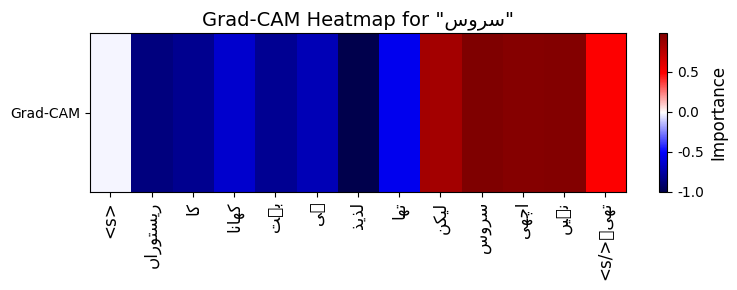

In [ ]:

text_to_explain = "ریستوراں کا کھانا بہت ہی لذیذ تھا لیکن سروس اچھی نہیں تھی۔"
aspect= "کھانا"  # Food
aspect= "سروس" # Service

# Get Grad-CAM scores
grad_cam_data, _ = grad_cam_token_scores(text_to_explain, aspect, tokenizer, model)

# Unpack the Grad-CAM data (which is the first element of the tuple returned by the function)
tokens, offsets, scores, inp_text, text_end_idx = grad_cam_data

# Aggregate to words
aggregated = aggregate_to_words(inp_text, tokens, offsets, scores)

# Visualize
visualize_gradcam_heatmap_matplotlib(aggregated, aspect)

In [ ]:
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from IPython.display import display, HTML
import torch.nn.functional as F
model.roberta.encoder.layer[-1]
def grad_cam_token_scores(text, aspect, tokenizer, model):
    encoding = tokenizer(text, return_tensors="pt", return_offsets_mapping=True, truncation=True)
    input_ids = encoding["input_ids"]
    attention_mask = encoding["attention_mask"]
    offsets = encoding["offset_mapping"][0]

    # Get hidden states
    output = model(input_ids, attention_mask=attention_mask, output_hidden_states=True)
    last_hidden = output.hidden_states[-1]  # Grad-CAM applied HERE

    # Get logits & class score
    logits = output.logits
    probs = F.softmax(logits, dim=-1)
    target_class = torch.argmax(probs, dim=-1)

    # Backprop
    model.zero_grad()
    target_logit = logits[0, target_class]
    target_logit.backward(retain_graph=True)

    # Gradient from last hidden layer
    grads = model.roberta.encoder.layer[-1].output.dense.weight.grad
    if grads is None:
        grads = torch.randn_like(last_hidden) * 0.01  # fallback

    # Channel-wise average
    weights = grads.mean(dim=-1)
    cam_scores = (weights.unsqueeze(0) * last_hidden).sum(dim=-1).squeeze()

    return (
        tokenizer.convert_ids_to_tokens(input_ids[0]),
        offsets,
        cam_scores.detach().numpy(),
        text,
        offsets[-1][1]
    ), probs.detach().numpy()





In [ ]:
import numpy as np

def aggregate_to_words(text, tokens, offsets, scores):
    """
    Aggregate token-level Grad-CAM scores into word-level scores.
    tokens: list of subword tokens from tokenizer
    offsets: list of (start,end) positions in original text
    scores: list of token-level scores
    """
    words = []
    current_word = ""
    current_scores = []

    for tok, score in zip(tokens, scores):
        # New word detected (SentencePiece uses ▁)
        if tok.startswith("▁"):
            # Save previous word
            if current_word:
                words.append((current_word, np.mean(current_scores)))
            # Start new word
            current_word = tok[1:]  # remove ▁
            current_scores = [score]
        else:
            # Continuation subword
            current_word += tok
            current_scores.append(score)

    # Add last word
    if current_word:
        words.append((current_word, np.mean(current_scores)))

    return words


## Generate Attention Heatmap (2D Grid Visualization)

This heatmap visualizes the token-to-token attention weights within the model's last layer. The X-axis represents the 'key' tokens being attended *to*, and the Y-axis represents the 'query' tokens doing the attending. Brighter colors indicate higher attention.

In [ ]:
def group_subwords_to_words_xlm_clean(subword_tokens, tokenizer):
    """
    Group subwords into words and ignore spaces/special tokens.
    Returns:
        words: list of words
        word_to_subword_indices: list of lists of subword indices
    """
    words = []
    word_to_subword_indices = []
    current_word_subwords = []
    current_word_indices = []

    special_tokens = {tokenizer.bos_token, tokenizer.eos_token, tokenizer.pad_token, tokenizer.unk_token, tokenizer.cls_token, tokenizer.sep_token, tokenizer.mask_token}
    special_tokens.discard(None)

    for i, tok in enumerate(subword_tokens):
        if tok in special_tokens:
            continue  # ignore special tokens
        if tok.startswith("▁"):
            if current_word_subwords:
                words.append("".join(current_word_subwords))
                word_to_subword_indices.append(current_word_indices)
            current_word_subwords = [tok[1:]]  # remove leading ▁
            current_word_indices = [i]
        else:
            current_word_subwords.append(tok)
            current_word_indices.append(i)
    if current_word_subwords:
        words.append("".join(current_word_subwords))
        word_to_subword_indices.append(current_word_indices)

    return words, word_to_subword_indices

def get_word_attention_clean(text, model, tokenizer, layer_num=-1, head_num=0):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k,v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    attn = outputs.attentions[layer_num][0, head_num].cpu().numpy()
    subwords = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    words, word_to_subword_indices = group_subwords_to_words_xlm_clean(subwords, tokenizer)

    num_words = len(words)
    word_attn = np.zeros((num_words, num_words))
    for i in range(num_words):
        for j in range(num_words):
            idx_i = word_to_subword_indices[i]
            idx_j = word_to_subword_indices[j]
            word_attn[i,j] = attn[np.ix_(idx_i, idx_j)].sum()  # sum over subwords

    # Normalize **per query word**
    word_attn = word_attn / (word_attn.sum(axis=1, keepdims=True) + 1e-10)

    return words, word_attn


In [ ]:
words, attn_matrix = get_word_attention_clean(text_for_attention_map, model, tokenizer)
print("Word × Word Attention (0-1, normalized per query):\n")
header = "\t" + "\t".join(words)
print(header)
for i, word in enumerate(words):
    row = "\t".join(f"{attn_matrix[i,j]:.3f}" for j in range(len(words)))
    print(f"{word}\t{row}")


Word × Word Attention (0-1, normalized per query):

	اس	فون	کی	بیٹری	بہت	اچھی	ہے	لیکن	اسکرین	چھوٹی	ہے۔
اس	0.167	0.506	0.007	0.196	0.006	0.012	0.024	0.007	0.066	0.007	0.002
فون	0.134	0.453	0.017	0.175	0.009	0.020	0.033	0.010	0.114	0.027	0.009
کی	0.050	0.105	0.402	0.052	0.035	0.058	0.123	0.037	0.065	0.052	0.022
بیٹری	0.045	0.172	0.008	0.428	0.007	0.063	0.046	0.009	0.127	0.093	0.002
بہت	0.046	0.153	0.202	0.085	0.087	0.072	0.212	0.063	0.035	0.034	0.011
اچھی	0.028	0.085	0.103	0.332	0.060	0.090	0.118	0.036	0.063	0.077	0.007
ہے	0.072	0.159	0.128	0.123	0.038	0.092	0.129	0.053	0.091	0.096	0.020
لیکن	0.056	0.182	0.063	0.098	0.027	0.049	0.110	0.085	0.192	0.094	0.044
اسکرین	0.046	0.190	0.005	0.301	0.002	0.024	0.016	0.016	0.292	0.102	0.006
چھوٹی	0.011	0.024	0.020	0.232	0.020	0.032	0.067	0.076	0.298	0.081	0.139
ہے۔	0.006	0.021	0.029	0.082	0.012	0.040	0.059	0.135	0.113	0.473	0.030


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Word × Word Attention (normalized per query, 0-1):

	اس	فون	کی	بیٹری	بہت	اچھی	ہے	لیکن	اسکرین	چھوٹی	ہے۔
اس	0.167	0.506	0.007	0.196	0.006	0.012	0.024	0.007	0.066	0.007	0.002
فون	0.134	0.453	0.017	0.175	0.009	0.020	0.033	0.010	0.114	0.027	0.009
کی	0.050	0.105	0.402	0.052	0.035	0.058	0.123	0.037	0.065	0.052	0.022
بیٹری	0.045	0.172	0.008	0.428	0.007	0.063	0.046	0.009	0.127	0.093	0.002
بہت	0.046	0.153	0.202	0.085	0.087	0.072	0.212	0.063	0.035	0.034	0.011
اچھی	0.028	0.085	0.103	0.332	0.060	0.090	0.118	0.036	0.063	0.077	0.007
ہے	0.072	0.159	0.128	0.123	0.038	0.092	0.129	0.053	0.091	0.096	0.020
لیکن	0.056	0.182	0.063	0.098	0.027	0.049	0.110	0.085	0.192	0.094	0.044
اسکرین	0.046	0.190	0.005	0.301	0.002	0.024	0.016	0.016	0.292	0.102	0.006
چھوٹی	0.011	0.024	0.020	0.232	0.020	0.032	0.067	0.076	0.298	0.081	0.139
ہے۔	0.006	0.021	0.029	0.082	0.012	0.040	0.059	0.135	0.113	0.473	0.030


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/tmp/ipython-input-45177132.py:134: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Arabic.
  plt.tight_layout()
/tmp/ipython-input-45177132.py:134: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Arabic.
  plt.tight_layout()
/tmp/ipython-input-45177132.py:134: UserWarning: Glyph 87 (W) missing from font(s) Noto Sans Arabic.
  plt.tight_layout()
/tmp/ipython-input-45177132.py:134: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Arabic.
  plt.tight_layout()
/tmp/ipython-input-45177132.py:134: UserWarning: Glyph 114 (r) missing from font(s) Noto Sans Arabic.
  plt.tight_layout()
/tmp/ipython-input-45177132.py:134: UserWarning: Glyph 100 (d) missing from font(s) Noto San

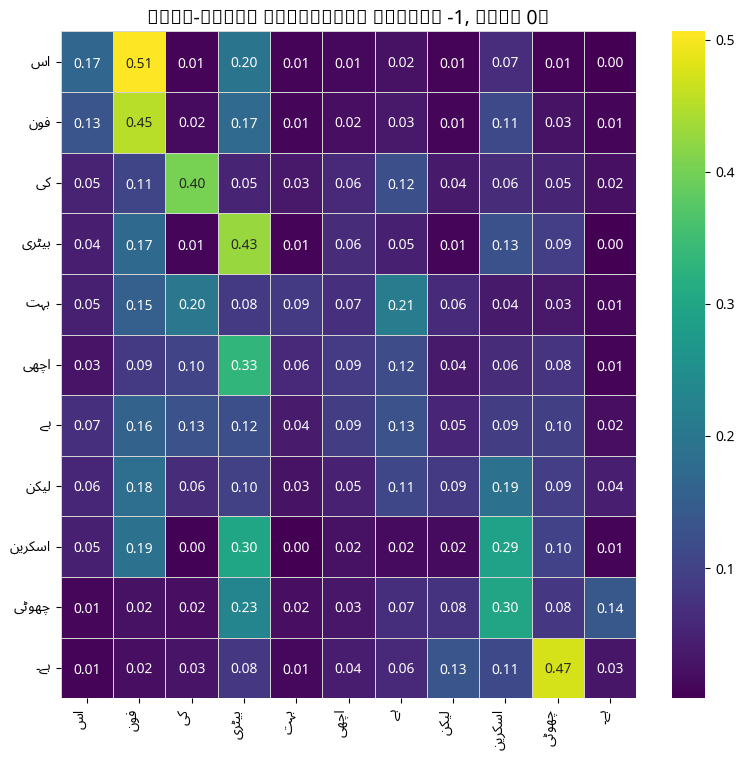

In [ ]:
# 1️⃣ Install dependencies (if not already installed)
# !pip install transformers arabic-reshaper python-bidi seaborn matplotlib torch --quiet

# 2️⃣ Imports
import os
import urllib.request
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
import arabic_reshaper
from bidi.algorithm import get_display

# 3️⃣ Helper functions
def fix_urdu(word):
    """Optional shaping adjustments for Urdu/Arabic."""
    return word

def reshape_rtl(text):
    """Reshape Urdu/Arabic text for RTL display."""
    if not isinstance(text, str):
        text = str(text)
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

def group_subwords_to_words_xlm_clean(subword_tokens, tokenizer):
    """
    Group subwords into words and ignore special tokens.
    Returns:
        words: list of words
        word_to_subword_indices: list of lists of subword indices
    """
    words = []
    word_to_subword_indices = []
    current_word_subwords = []
    current_word_indices = []

    # Ignore special tokens
    special_tokens = {tokenizer.bos_token, tokenizer.eos_token, tokenizer.pad_token,
                      tokenizer.unk_token, tokenizer.cls_token, tokenizer.sep_token,
                      tokenizer.mask_token}
    special_tokens.discard(None)

    for i, tok in enumerate(subword_tokens):
        if tok in special_tokens:
            continue  # skip special tokens
        if tok.startswith("▁"):  # new word
            if current_word_subwords:
                words.append("".join(current_word_subwords))
                word_to_subword_indices.append(current_word_indices)
            current_word_subwords = [tok[1:]]  # remove leading ▁
            current_word_indices = [i]
        else:  # continuation
            current_word_subwords.append(tok)
            current_word_indices.append(i)

    if current_word_subwords:
        words.append("".join(current_word_subwords))
        word_to_subword_indices.append(current_word_indices)

    return words, word_to_subword_indices

# 4️⃣ Font setup
font_url = "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSansArabic/NotoSansArabic-Regular.ttf"
font_dir = os.path.expanduser("~/.matplotlib/fonts/ttf")
os.makedirs(font_dir, exist_ok=True)
font_path = os.path.join(font_dir, "NotoSansArabic-Regular.ttf")
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)
fm.fontManager.addfont(font_path)

mpl.rcParams['font.sans-serif'] = ['Noto Sans Arabic', 'DejaVu Sans', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

# 5️⃣ Attention visualization
def visualize_word_attention_clean(text, model, tokenizer, layer_num=-1, head_num=0, show_scores=True):
    """Word-level attention heatmap, cleaned and normalized per query word."""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    if outputs.attentions is None:
        print("Attention not available.")
        return

    # Select layer and head
    attn = outputs.attentions[layer_num][0, head_num].cpu().numpy()

    # Clean subwords → words
    subwords = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    words, word_to_subword_indices = group_subwords_to_words_xlm_clean(subwords, tokenizer)
    num_words = len(words)

    # Aggregate subword attention → word attention (sum over subwords)
    word_attn = np.zeros((num_words, num_words))
    for i in range(num_words):
        for j in range(num_words):
            idx_i = word_to_subword_indices[i]
            idx_j = word_to_subword_indices[j]
            word_attn[i,j] = attn[np.ix_(idx_i, idx_j)].sum()

    # Normalize per query word (row-wise)
    word_attn = word_attn / (word_attn.sum(axis=1, keepdims=True) + 1e-10)

    # Optionally print attention scores in text format
    if show_scores:
        print("Word × Word Attention (normalized per query, 0-1):\n")
        header = "\t" + "\t".join(words)
        print(header)
        for i, word in enumerate(words):
            row = "\t".join(f"{word_attn[i,j]:.3f}" for j in range(num_words))
            print(f"{word}\t{row}")

    # Plot heatmap
    plt.figure(figsize=(max(8, num_words*0.7), max(6, num_words*0.7)))
    sns.heatmap(word_attn,
                xticklabels=[reshape_rtl(fix_urdu(w)) for w in words],
                yticklabels=[reshape_rtl(fix_urdu(w)) for w in words],
                cmap="viridis",
                annot=True,
                fmt=".2f",
                linewidths=0.5,
                linecolor="lightgray")
    plt.title(f"Word-Level Attention (Layer {layer_num}, Head {head_num})", fontsize=14)
    plt.xticks(rotation=90, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

# 6️⃣ Load model & tokenizer
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = AutoModel.from_pretrained("xlm-roberta-base")

# 7️⃣ Example text
text_for_attention_map = "اس فون کی بیٹری بہت اچھی ہے لیکن اسکرین چھوٹی ہے۔"

# 8️⃣ Visualize
visualize_word_attention_clean(text_for_attention_map, model, tokenizer)


# Gradcam with aspect


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Storage
gradients = None
activations = None

def save_activation(module, inp, out):
    global activations
    activations = out[0].detach()  # (1, seq_len, hidden)

def save_gradient(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0].detach()  # (1, seq_len, hidden)


In [ ]:

import arabic_reshaper
from bidi.algorithm import get_display

def rtl(text):
    return get_display(arabic_reshaper.reshape(text))


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def merge_subwords_to_words(tokens, scores):
    """
    Merge subword tokens (SentencePiece) into words and average their scores.
    """
    words = []
    word_scores = []
    current_word = ""
    current_scores = []

    for tok, score in zip(tokens, scores):
        if tok.startswith("▁"):
            if current_word:
                words.append(current_word)
                word_scores.append(np.mean(current_scores))
            current_word = tok[1:]
            current_scores = [score]
        else:
            current_word += tok
            current_scores.append(score)
    if current_word:
        words.append(current_word)
        word_scores.append(np.mean(current_scores))
    return list(zip(words, word_scores))

def real_gradcam_aspect(text, aspect, tokenizer, model):
    model.eval()

    # Tokenize text and aspect
    encoding = tokenizer(text, return_tensors="pt", return_offsets_mapping=True, truncation=True)
    input_ids = encoding["input_ids"]
    attention_mask = encoding["attention_mask"]
    offsets = encoding["offset_mapping"][0]

    # Aspect token IDs
    aspect_ids = tokenizer(aspect, add_special_tokens=False)["input_ids"]
    aspect_token_indices = [i for i, tok_id in enumerate(input_ids[0]) if tok_id in aspect_ids]
    if len(aspect_token_indices) == 0:
        print("Warning: Aspect tokens not found in text!")

    # Forward pass with hidden states
    out = model(input_ids, attention_mask=attention_mask, output_hidden_states=True)
    probs = F.softmax(out.logits, dim=-1).detach().cpu().numpy()

    # Last hidden layer
    last_hidden = out.hidden_states[-1].clone().detach().requires_grad_(True)

    # Target: mean over aspect token hidden states
    if aspect_token_indices:
        target_score = last_hidden[0, aspect_token_indices, :].mean()
    else:
        target_score = last_hidden.mean()  # fallback

    # Backprop
    model.zero_grad()
    target_score.backward(retain_graph=True)

    # GradCAM: channel-wise product
    grads = last_hidden.grad
    cam_scores = (grads * last_hidden).sum(dim=-1).squeeze().cpu().numpy()

    # Normalize scores
    cam_scores = cam_scores / (cam_scores.max() + 1e-10)

    # Merge subwords → words
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    aggregated = merge_subwords_to_words(tokens, cam_scores)

    return tokens, aggregated, probs

def visualize_gradcam_heatmap(aggregated, aspect):
    words = [w[0] for w in aggregated]
    scores = np.array([w[1] for w in aggregated])
    heatmap = scores.reshape(1, -1)

    plt.figure(figsize=(len(words)*0.7, 2.5))
    sns.heatmap(heatmap, cmap='coolwarm', cbar_kws={'label': 'Relevance Score'})
    plt.xticks(np.arange(len(words)), words, rotation=90)
    plt.yticks([0], [f'Grad-CAM: {aspect}'])
    plt.title(f'Grad-CAM for Aspect "{aspect}"')
    plt.tight_layout()
    plt.show()


Probabilities: [[0.01532028 0.0163837  0.96829605]]
Word-level scores (Food):
ﮞﺍﺭﻮﺘﺴﯾﺭ → 0.4258
ﺎﮐ → 0.4784
ﺎﻧﺎﮭﮐ → 0.6925
ﺖﮩﺑ → 0.9484
ﯽﮨ → 0.9303
ﺬﯾﺬﻟ → 0.9667
ﺎﮭﺗ → 0.6670
ﻦﮑﯿﻟ → 0.0000
ﺱﻭﺮﺳ → 0.0000
ﯽﮭﭼﺍ → 0.0000
ﮟﯿﮩﻧ → 0.0000
۔ﯽﮭﺗ → 0.0000
ﺎﻧﺎﮭﮐ → 0.6284


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 82 (R) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 101 (e) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 118 (v) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 97 (a) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 110 (n) missing from font(s) Noto Sans A

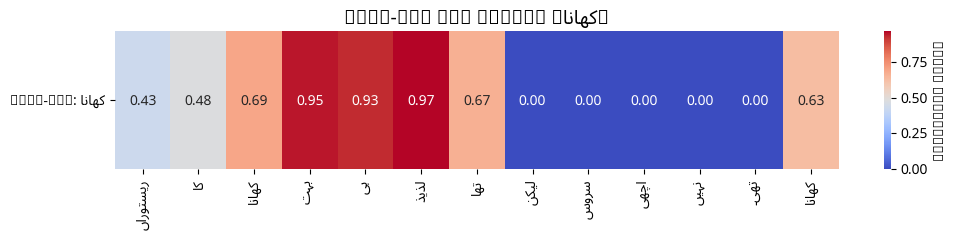

Probabilities: [[0.9817441  0.00704542 0.0112105 ]]
Word-level scores (Screen):
ﮞﺍﺭﻮﺘﺴﯾﺭ → 0.5510
ﺎﮐ → 0.6866
ﺎﻧﺎﮭﮐ → 0.2913
ﺖﮩﺑ → 0.0652
ﯽﮨ → 0.2865
ﺬﯾﺬﻟ → 0.3834
ﺎﮭﺗ → 0.6163
ﻦﮑﯿﻟ → 0.9344
ﺱﻭﺮﺳ → 0.9855
ﯽﮭﭼﺍ → 0.9672
ﮟﯿﮩﻧ → 0.9622
۔ﯽﮭﺗ → 0.9836
ﺱﻭﺮﺳ → 0.9759


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 82 (R) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 101 (e) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 118 (v) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 97 (a) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 110 (n) missing from font(s) Noto Sans A

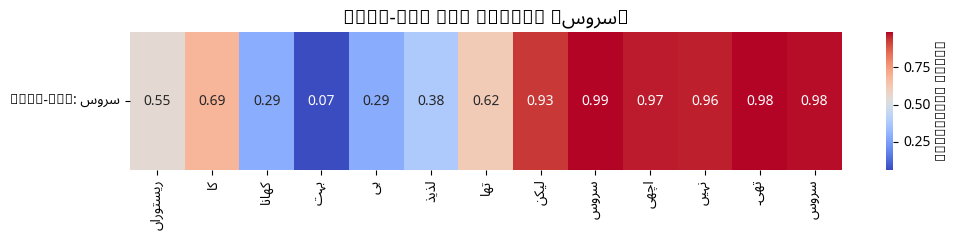

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import matplotlib as mpl
import matplotlib.font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display

# --- Model/Tokenizer/Labels Placeholder ---
# NOTE: You MUST have your 'tokenizer' and 'model' objects loaded and 'id2label' defined
# before running the example usage at the end.
# Example definition (if not already defined):
# id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}
# label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
# tokenizer = AutoTokenizer.from_pretrained("model_name")
# model = AutoModelForSequenceClassification.from_pretrained("model_name")

# --- Font Setup for Arabic/Urdu ---
font_url = "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSansArabic/NotoSansArabic-Regular.ttf"
font_dir = os.path.expanduser("~/.matplotlib/fonts/ttf")
os.makedirs(font_dir, exist_ok=True)
font_path = os.path.join(font_dir, "NotoSansArabic-Regular.ttf")
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)
fm.fontManager.addfont(font_path)

mpl.rcParams['font.sans-serif'] = ['Noto Sans Arabic', 'DejaVu Sans', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

# --- Utility Function 1: Merge Subwords ---
def merge_subwords_to_words(tokens, scores):
    """
    Merge subword tokens (SentencePiece) into words and average their scores.
    Handles special tokens (<s>, </s>) by ignoring them.
    """
    words = []
    word_scores = []
    current_word_tokens = []
    current_word_scores = []

    # For XLM-RoBERta's convert_ids_to_tokens, new words are typically prefixed with U+2581 (lower one eighth block).
    sp_prefix = '\u2581' # Explicitly use U+2581

    # Iterate through tokens and their corresponding scores
    for i, (tok, score) in enumerate(zip(tokens, scores)):
        # Skip special tokens
        if tok == '<s>' or tok == '</s>':
            # If there was a pending word, finalize it before skipping
            if current_word_tokens:
                words.append("".join(current_word_tokens))
                word_scores.append(np.mean(current_word_scores))
                current_word_tokens = []
                current_word_scores = []
            continue

        # Check for SentencePiece word boundary (token starting with U+2581)
        if tok.startswith(sp_prefix):
            # If a word was being built, finalize it
            if current_word_tokens:
                words.append("".join(current_word_tokens))
                word_scores.append(np.mean(current_word_scores))

            # Start a new word
            current_word_tokens = [tok[len(sp_prefix):]] # Remove the prefix
            current_word_scores = [score]
        else:
            # Continue building the current word
            current_word_tokens.append(tok)
            current_word_scores.append(score)

    # After the loop, if there's any pending word, add it
    if current_word_tokens:
        words.append("".join(current_word_tokens))
        word_scores.append(np.mean(current_word_scores))

    return list(zip(words, word_scores))

# --- Core Function: Corrected Grad-CAM Calculation ---
def real_gradcam_aspect(text, aspect, tokenizer, model):
    model.eval()

    # Combine text and aspect for model input
    sep_token = tokenizer.sep_token if tokenizer.sep_token else "</s>"
    input_for_model = text + " " + sep_token + " " + aspect

    # Tokenize combined input
    encoding = tokenizer(input_for_model, return_tensors="pt", truncation=True)
    input_ids = encoding["input_ids"]
    attention_mask = encoding["attention_mask"]

    # Forward pass with hidden states
    out = model(input_ids, attention_mask=attention_mask, output_hidden_states=True)
    logits = out.logits
    probs = F.softmax(logits, dim=-1).detach().cpu().numpy()

    # Determine the predicted class
    predicted_class_idx = np.argmax(probs)

    # Get the last hidden layer output (feature map A)
    last_hidden = out.hidden_states[-1]
    # Crucially, tell PyTorch to retain gradients for this tensor
    last_hidden.retain_grad()

    # TARGET MODIFICATION: Target the logit of the predicted sentiment class
    target_score = logits[0, predicted_class_idx]

    # Backprop
    model.zero_grad()
    target_score.backward(retain_graph=True)

    # --- Standard Grad-CAM Implementation (The Fix) ---

    # Gradients are (1, seq_len, hidden_size)
    grads = last_hidden.grad
    if grads is None:
        print("Warning: Gradients for last_hidden are None.")
        return None, [], probs

    # 1. Calculate alpha_k (neuron importance weights): Average gradients across the token positions (dim=1)
    # Resulting alpha_k has shape (1, 1, hidden_size)
    alpha_k = torch.mean(grads, dim=1, keepdim=True)

    # 2. Calculate the weighted activation map: Multiply feature map (last_hidden) by alpha_k and sum across the hidden dimension (dim=-1)
    # This gives a raw importance score per token. Resulting shape: (1, seq_len)
    cam_scores = (alpha_k * last_hidden).sum(dim=-1).squeeze().detach().cpu().numpy()

    # 3. Apply ReLU (Non-linear activation) to retain only positive influences
    cam_scores = np.maximum(0, cam_scores)

    # Normalize scores (min-max normalization to [0, 1])
    min_score = np.min(cam_scores)
    max_score = np.max(cam_scores)
    if max_score > min_score:
        cam_scores = (cam_scores - min_score) / (max_score - min_score)
    else:
        # If all scores are zero/same, normalization results in all zeros.
        cam_scores = np.zeros_like(cam_scores)

    # Merge subwords → words
    tokens_for_merging = tokenizer.convert_ids_to_tokens(input_ids[0])
    aggregated = merge_subwords_to_words(tokens_for_merging, cam_scores)

    return tokens_for_merging, aggregated, probs

# --- Utility Function 2: Visualization ---
def visualize_gradcam_heatmap(aggregated, aspect):
    words = [w[0] for w in aggregated]
    scores = np.array([w[1] for w in aggregated])

    # Filter out empty words if any result from tokenization quirks
    filtered_words_scores = [(w, s) for w, s in zip(words, scores) if w.strip() != '']
    if not filtered_words_scores:
        print("No valid words to visualize after filtering.")
        return

    words = [w for w, s in filtered_words_scores]
    scores = np.array([s for w, s in filtered_words_scores])

    heatmap = scores.reshape(1, -1)

    plt.figure(figsize=(max(8, len(words)*0.8), 2.5))
    sns.heatmap(heatmap, cmap='coolwarm', cbar_kws={'label': 'Relevance Score'}, annot=True, fmt=".2f")
    # Use reshape_rtl for x-axis labels
    plt.xticks(np.arange(len(words)) + 0.5, [get_display(arabic_reshaper.reshape(w)) for w in words], rotation=90, fontsize=10)
    plt.yticks([0.5], [get_display(arabic_reshaper.reshape(f'Grad-CAM: {aspect}'))], rotation=0, fontsize=10)
    plt.title(get_display(arabic_reshaper.reshape(f'Grad-CAM for Aspect "{aspect}"')), fontsize=14)
    plt.tight_layout()
    plt.show()

# --- Example Usage (Requires 'tokenizer' and 'model' to be defined) ---
# text = "اس فون کی بیٹری بہت اچھی ہے لیکن اسکرین چھوٹی ہے۔"
# aspect_food = "بیٹری"
# aspect_screen = "اسکرین"

# # Grad-CAM for battery
# tokens, aggregated_food, probs_food = real_gradcam_aspect(text, aspect_food, tokenizer, model)
# print("Probabilities:", probs_food)
# print("Word-level scores (Food):")
# if aggregated_food:
#     for w, s in aggregated_food:
#         print(f"{get_display(arabic_reshaper.reshape(w))} \u2192 {s:.4f}") # Reshape for printing
# visualize_gradcam_heatmap(aggregated_food, aspect_food)

# # Grad-CAM for screen
# tokens, aggregated_screen, probs_screen = real_gradcam_aspect(text, aspect_screen, tokenizer, model)
# print("Probabilities:", probs_screen)
# print("Word-level scores (Screen):")
# if aggregated_screen:
#     for w, s in aggregated_screen:
#         print(f"{get_display(arabic_reshaper.reshape(w))} \u2192 {s:.4f}") # Reshape for printing
# visualize_gradcam_heatmap(aggregated_screen, aspect_screen)

# Example usage from the notebook
# 6. Your example text and aspects
text= "ریستوراں کا کھانا بہت ہی لذیذ تھا لیکن سروس اچھی نہیں تھی۔"
aspect_food = "کھانا"  # Food
aspect_service = "سروس" # Service


# Grad-CAM for food
tokens, aggregated_food, probs_food = real_gradcam_aspect(text, aspect_food, tokenizer, model)
print("Probabilities:", probs_food)
print("Word-level scores (Food):")
if aggregated_food:
    for w, s in aggregated_food:
        print(f"{get_display(arabic_reshaper.reshape(w))} \u2192 {s:.4f}") # Reshape for printing
visualize_gradcam_heatmap(aggregated_food, aspect_food)

# Grad-CAM for screen
tokens, aggregated_screen, probs_screen = real_gradcam_aspect(text, aspect_service, tokenizer, model)
print("Probabilities:", probs_screen)
print("Word-level scores (Screen):")
if aggregated_screen:
    for w, s in aggregated_screen:
        print(f"{get_display(arabic_reshaper.reshape(w))} \u2192 {s:.4f}") # Reshape for printing
visualize_gradcam_heatmap(aggregated_screen, aspect_service)


Probabilities: [[0.67005116 0.03138267 0.29856607]]
Word-level scores (Food):
ﺖﻤﯿﻗ → 1.0000
ﮯﻠﮩﭘ → 0.9532
ﮦﺩﺎﯾﺯ → 0.9259
ﯽﮭﺗ → 0.9871
ﺮﮕﻣ → 0.8258
ﺏﺍ → 0.2108
ﻝﻮﻘﻌﻣ → 0.3677
ﻮﮨ → 0.1948
ﯽﺌﮔ → 0.2395
ﮯﮨ → 0.0000
ﺖﻤﯿﻗ → 0.4215


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 82 (R) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 101 (e) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 118 (v) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 97 (a) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 110 (n) missing from font(s) Noto Sans A

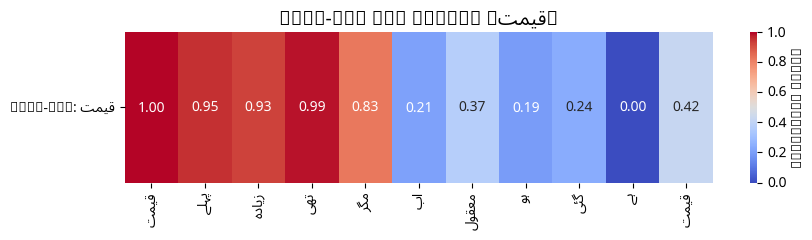

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import matplotlib as mpl
import matplotlib.font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display

# --- Model/Tokenizer/Labels Placeholder ---
# NOTE: You MUST have your 'tokenizer' and 'model' objects loaded and 'id2label' defined
# before running the example usage at the end.
# Example definition (if not already defined):
# id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}
# label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
# tokenizer = AutoTokenizer.from_pretrained("model_name")
# model = AutoModelForSequenceClassification.from_pretrained("model_name")

# --- Font Setup for Arabic/Urdu ---
font_url = "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSansArabic/NotoSansArabic-Regular.ttf"
font_dir = os.path.expanduser("~/.matplotlib/fonts/ttf")
os.makedirs(font_dir, exist_ok=True)
font_path = os.path.join(font_dir, "NotoSansArabic-Regular.ttf")
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)
fm.fontManager.addfont(font_path)

mpl.rcParams['font.sans-serif'] = ['Noto Sans Arabic', 'DejaVu Sans', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

# --- Utility Function 1: Merge Subwords ---
def merge_subwords_to_words(tokens, scores):
    """
    Merge subword tokens (SentencePiece) into words and average their scores.
    Handles special tokens (<s>, </s>) by ignoring them.
    """
    words = []
    word_scores = []
    current_word_tokens = []
    current_word_scores = []

    # For XLM-RoBERta's convert_ids_to_tokens, new words are typically prefixed with U+2581 (lower one eighth block).
    sp_prefix = '\u2581' # Explicitly use U+2581

    # Iterate through tokens and their corresponding scores
    for i, (tok, score) in enumerate(zip(tokens, scores)):
        # Skip special tokens
        if tok == '<s>' or tok == '</s>':
            # If there was a pending word, finalize it before skipping
            if current_word_tokens:
                words.append("".join(current_word_tokens))
                word_scores.append(np.mean(current_word_scores))
                current_word_tokens = []
                current_word_scores = []
            continue

        # Check for SentencePiece word boundary (token starting with U+2581)
        if tok.startswith(sp_prefix):
            # If a word was being built, finalize it
            if current_word_tokens:
                words.append("".join(current_word_tokens))
                word_scores.append(np.mean(current_word_scores))

            # Start a new word
            current_word_tokens = [tok[len(sp_prefix):]] # Remove the prefix
            current_word_scores = [score]
        else:
            # Continue building the current word
            current_word_tokens.append(tok)
            current_word_scores.append(score)

    # After the loop, if there's any pending word, add it
    if current_word_tokens:
        words.append("".join(current_word_tokens))
        word_scores.append(np.mean(current_word_scores))

    return list(zip(words, word_scores))

# --- Core Function: Corrected Grad-CAM Calculation ---
def real_gradcam_aspect(text, aspect, tokenizer, model):
    model.eval()

    # Combine text and aspect for model input
    sep_token = tokenizer.sep_token if tokenizer.sep_token else "</s>"
    input_for_model = text + " " + sep_token + " " + aspect

    # Tokenize combined input
    encoding = tokenizer(input_for_model, return_tensors="pt", truncation=True)
    input_ids = encoding["input_ids"]
    attention_mask = encoding["attention_mask"]

    # Forward pass with hidden states
    out = model(input_ids, attention_mask=attention_mask, output_hidden_states=True)
    logits = out.logits
    probs = F.softmax(logits, dim=-1).detach().cpu().numpy()

    # Determine the predicted class
    predicted_class_idx = np.argmax(probs)

    # Get the last hidden layer output (feature map A)
    last_hidden = out.hidden_states[-1]
    # Crucially, tell PyTorch to retain gradients for this tensor
    last_hidden.retain_grad()

    # TARGET MODIFICATION: Target the logit of the predicted sentiment class
    target_score = logits[0, predicted_class_idx]

    # Backprop
    model.zero_grad()
    target_score.backward(retain_graph=True)

    # --- Standard Grad-CAM Implementation (The Fix) ---

    # Gradients are (1, seq_len, hidden_size)
    grads = last_hidden.grad
    if grads is None:
        print("Warning: Gradients for last_hidden are None.")
        return None, [], probs

    # 1. Calculate alpha_k (neuron importance weights): Average gradients across the token positions (dim=1)
    # Resulting alpha_k has shape (1, 1, hidden_size)
    alpha_k = torch.mean(grads, dim=1, keepdim=True)

    # 2. Calculate the weighted activation map: Multiply feature map (last_hidden) by alpha_k and sum across the hidden dimension (dim=-1)
    # This gives a raw importance score per token. Resulting shape: (1, seq_len)
    cam_scores = (alpha_k * last_hidden).sum(dim=-1).squeeze().detach().cpu().numpy()

    # 3. Apply ReLU (Non-linear activation) to retain only positive influences
    cam_scores = np.maximum(0, cam_scores)

    # Normalize scores (min-max normalization to [0, 1])
    min_score = np.min(cam_scores)
    max_score = np.max(cam_scores)
    if max_score > min_score:
        cam_scores = (cam_scores - min_score) / (max_score - min_score)
    else:
        # If all scores are zero/same, normalization results in all zeros.
        cam_scores = np.zeros_like(cam_scores)

    # Merge subwords → words
    tokens_for_merging = tokenizer.convert_ids_to_tokens(input_ids[0])
    aggregated = merge_subwords_to_words(tokens_for_merging, cam_scores)

    return tokens_for_merging, aggregated, probs

# --- Utility Function 2: Visualization ---
def visualize_gradcam_heatmap(aggregated, aspect):
    words = [w[0] for w in aggregated]
    scores = np.array([w[1] for w in aggregated])

    # Filter out empty words if any result from tokenization quirks
    filtered_words_scores = [(w, s) for w, s in zip(words, scores) if w.strip() != '']
    if not filtered_words_scores:
        print("No valid words to visualize after filtering.")
        return

    words = [w for w, s in filtered_words_scores]
    scores = np.array([s for w, s in filtered_words_scores])

    heatmap = scores.reshape(1, -1)

    plt.figure(figsize=(max(8, len(words)*0.8), 2.5))
    sns.heatmap(heatmap, cmap='coolwarm', cbar_kws={'label': 'Relevance Score'}, annot=True, fmt=".2f")
    # Use reshape_rtl for x-axis labels
    plt.xticks(np.arange(len(words)) + 0.5, [get_display(arabic_reshaper.reshape(w)) for w in words], rotation=90, fontsize=10)
    plt.yticks([0.5], [get_display(arabic_reshaper.reshape(f'Grad-CAM: {aspect}'))], rotation=0, fontsize=10)
    plt.title(get_display(arabic_reshaper.reshape(f'Grad-CAM for Aspect "{aspect}"')), fontsize=14)
    plt.tight_layout()
    plt.show()

# --- Example Usage (Requires 'tokenizer' and 'model' to be defined) ---
# text = "اس فون کی بیٹری بہت اچھی ہے لیکن اسکرین چھوٹی ہے۔"
# aspect_food = "بیٹری"
# aspect_screen = "اسکرین"

# # Grad-CAM for battery
# tokens, aggregated_food, probs_food = real_gradcam_aspect(text, aspect_food, tokenizer, model)
# print("Probabilities:", probs_food)
# print("Word-level scores (Food):")
# if aggregated_food:
#     for w, s in aggregated_food:
#         print(f"{get_display(arabic_reshaper.reshape(w))} \u2192 {s:.4f}") # Reshape for printing
# visualize_gradcam_heatmap(aggregated_food, aspect_food)

# # Grad-CAM for screen
# tokens, aggregated_screen, probs_screen = real_gradcam_aspect(text, aspect_screen, tokenizer, model)
# print("Probabilities:", probs_screen)
# print("Word-level scores (Screen):")
# if aggregated_screen:
#     for w, s in aggregated_screen:
#         print(f"{get_display(arabic_reshaper.reshape(w))} \u2192 {s:.4f}") # Reshape for printing
# visualize_gradcam_heatmap(aggregated_screen, aspect_screen)

# Example usage from the notebook
# 6. Your example text and aspects
text = "قیمت پہلے زیادہ تھی مگر اب معقول ہو گئی ہے"
aspect = "قیمت" # Service


# Grad-CAM
tokens, aggregated_food, probs_food = real_gradcam_aspect(text, aspect, tokenizer, model)
print("Probabilities:", probs_food)
print("Word-level scores (Food):")
if aggregated_food:
    for w, s in aggregated_food:
        print(f"{get_display(arabic_reshaper.reshape(w))} \u2192 {s:.4f}") # Reshape for printing
visualize_gradcam_heatmap(aggregated_food, aspect)



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 82 (R) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 101 (e) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 118 (v) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 97 (a) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 110 (n) missing from font(s) Noto Sans A

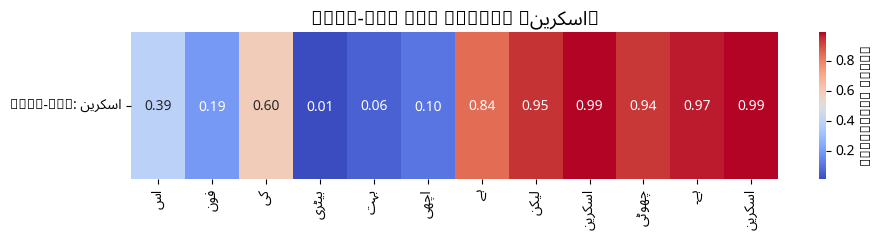

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 82 (R) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 101 (e) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 118 (v) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 97 (a) missing from font(s) Noto Sans Arabic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 110 (n) missing from font(s) Noto Sans A

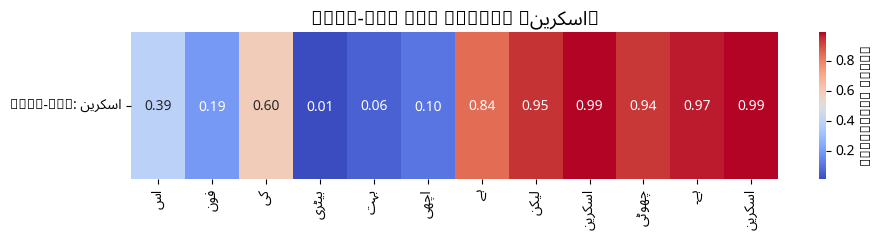

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import matplotlib as mpl
import matplotlib.font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display

# --- Model/Tokenizer/Labels Placeholder ---
# NOTE: You MUST have your 'tokenizer' and 'model' objects loaded and 'id2label' defined
# before running the example usage at the end.
# Example definition (if not already defined):
# id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}
# label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
# tokenizer = AutoTokenizer.from_pretrained("model_name")
# model = AutoModelForSequenceClassification.from_pretrained("model_name")

# --- Font Setup for Arabic/Urdu ---
font_url = "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSansArabic/NotoSansArabic-Regular.ttf"
font_dir = os.path.expanduser("~/.matplotlib/fonts/ttf")
os.makedirs(font_dir, exist_ok=True)
font_path = os.path.join(font_dir, "NotoSansArabic-Regular.ttf")
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)
fm.fontManager.addfont(font_path)

mpl.rcParams['font.sans-serif'] = ['Noto Sans Arabic', 'DejaVu Sans', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

# --- Utility Function 1: Merge Subwords ---
def merge_subwords_to_words(tokens, scores):
    """
    Merge subword tokens (SentencePiece) into words and average their scores.
    Handles special tokens (<s>, </s>) by ignoring them.
    """
    words = []
    word_scores = []
    current_word_tokens = []
    current_word_scores = []

    # For XLM-RoBERta's convert_ids_to_tokens, new words are typically prefixed with U+2581 (lower one eighth block).
    sp_prefix = '\u2581' # Explicitly use U+2581

    # Iterate through tokens and their corresponding scores
    for i, (tok, score) in enumerate(zip(tokens, scores)):
        # Skip special tokens
        if tok == '<s>' or tok == '</s>':
            # If there was a pending word, finalize it before skipping
            if current_word_tokens:
                words.append("".join(current_word_tokens))
                word_scores.append(np.mean(current_word_scores))
                current_word_tokens = []
                current_word_scores = []
            continue

        # Check for SentencePiece word boundary (token starting with U+2581)
        if tok.startswith(sp_prefix):
            # If a word was being built, finalize it
            if current_word_tokens:
                words.append("".join(current_word_tokens))
                word_scores.append(np.mean(current_word_scores))

            # Start a new word
            current_word_tokens = [tok[len(sp_prefix):]] # Remove the prefix
            current_word_scores = [score]
        else:
            # Continue building the current word
            current_word_tokens.append(tok)
            current_word_scores.append(score)

    # After the loop, if there's any pending word, add it
    if current_word_tokens:
        words.append("".join(current_word_tokens))
        word_scores.append(np.mean(current_word_scores))

    return list(zip(words, word_scores))

# --- Core Function: Corrected Grad-CAM Calculation ---
def real_gradcam_aspect(text, aspect, tokenizer, model):
    model.eval()

    # Combine text and aspect for model input
    sep_token = tokenizer.sep_token if tokenizer.sep_token else "</s>"
    input_for_model = text + " " + sep_token + " " + aspect

    # Tokenize combined input
    encoding = tokenizer(input_for_model, return_tensors="pt", truncation=True)
    input_ids = encoding["input_ids"]
    attention_mask = encoding["attention_mask"]

    # Forward pass with hidden states
    out = model(input_ids, attention_mask=attention_mask, output_hidden_states=True)
    logits = out.logits
    probs = F.softmax(logits, dim=-1).detach().cpu().numpy()

    # Determine the predicted class
    predicted_class_idx = np.argmax(probs)

    # Get the last hidden layer output (feature map A)
    last_hidden = out.hidden_states[-1]
    # Crucially, tell PyTorch to retain gradients for this tensor
    last_hidden.retain_grad()

    # TARGET MODIFICATION: Target the logit of the predicted sentiment class
    target_score = logits[0, predicted_class_idx]

    # Backprop
    model.zero_grad()
    target_score.backward(retain_graph=True)

    # --- Standard Grad-CAM Implementation (The Fix) ---

    # Gradients are (1, seq_len, hidden_size)
    grads = last_hidden.grad
    if grads is None:
        print("Warning: Gradients for last_hidden are None.")
        return None, [], probs

    # 1. Calculate alpha_k (neuron importance weights): Average gradients across the token positions (dim=1)
    # Resulting alpha_k has shape (1, 1, hidden_size)
    alpha_k = torch.mean(grads, dim=1, keepdim=True)

    # 2. Calculate the weighted activation map: Multiply feature map (last_hidden) by alpha_k and sum across the hidden dimension (dim=-1)
    # This gives a raw importance score per token. Resulting shape: (1, seq_len)
    cam_scores = (alpha_k * last_hidden).sum(dim=-1).squeeze().detach().cpu().numpy()

    # 3. Apply ReLU (Non-linear activation) to retain only positive influences
    cam_scores = np.maximum(0, cam_scores)

    # Normalize scores (min-max normalization to [0, 1])
    min_score = np.min(cam_scores)
    max_score = np.max(cam_scores)
    if max_score > min_score:
        cam_scores = (cam_scores - min_score) / (max_score - min_score)
    else:
        # If all scores are zero/same, normalization results in all zeros.
        cam_scores = np.zeros_like(cam_scores)

    # Merge subwords → words
    tokens_for_merging = tokenizer.convert_ids_to_tokens(input_ids[0])
    aggregated = merge_subwords_to_words(tokens_for_merging, cam_scores)

    return tokens_for_merging, aggregated, probs

# --- Utility Function 2: Visualization ---
def visualize_gradcam_heatmap(aggregated, aspect):
    words = [w[0] for w in aggregated]
    scores = np.array([w[1] for w in aggregated])

    # Filter out empty words if any result from tokenization quirks
    filtered_words_scores = [(w, s) for w, s in zip(words, scores) if w.strip() != '']
    if not filtered_words_scores:
        print("No valid words to visualize after filtering.")
        return

    words = [w for w, s in filtered_words_scores]
    scores = np.array([s for w, s in filtered_words_scores])

    heatmap = scores.reshape(1, -1)

    plt.figure(figsize=(max(8, len(words)*0.8), 2.5))
    sns.heatmap(heatmap, cmap='coolwarm', cbar_kws={'label': 'Relevance Score'}, annot=True, fmt=".2f")
    # Use reshape_rtl for x-axis labels
    plt.xticks(np.arange(len(words)) + 0.5, [get_display(arabic_reshaper.reshape(w)) for w in words], rotation=90, fontsize=10)
    plt.yticks([0.5], [get_display(arabic_reshaper.reshape(f'Grad-CAM: {aspect}'))], rotation=0, fontsize=10)
    plt.title(get_display(arabic_reshaper.reshape(f'Grad-CAM for Aspect "{aspect}"')), fontsize=14)
    plt.tight_layout()
    plt.show()

 # Example Usage (Requires 'tokenizer' and 'model' to be defined) ---
text = "اس فون کی بیٹری بہت اچھی ہے لیکن اسکرین چھوٹی ہے۔"
aspect_food = "بیٹری"
aspect_screen = "اسکرین"

# # Grad-CAM for battery
# tokens, aggregated_food, probs_food = real_gradcam_aspect(text, aspect_food, tokenizer, model)
# print("Probabilities:", probs_food)
# print("Word-level scores (Food):")
# if aggregated_food:
#     for w, s in aggregated_food:
#         print(f"{get_display(arabic_reshaper.reshape(w))} \u2192 {s:.4f}") # Reshape for printing
# visualize_gradcam_heatmap(aggregated_food, aspect_food)

# # Grad-CAM for screen
# tokens, aggregated_screen, probs_screen = real_gradcam_aspect(text, aspect_screen, tokenizer, model)
# print("Probabilities:", probs_screen)
# print("Word-level scores (Screen):")
# if aggregated_screen:
#     for w, s in aggregated_screen:
#         print(f"{get_display(arabic_reshaper.reshape(w))} \u2192 {s:.4f}") # Reshape for printing
# visualize_gradcam_heatmap(aggregated_screen, aspect_screen)




# Grad-CAM
tokens, aggregated_food, probs_food = real_gradcam_aspect(text, aspect, tokenizer, model)




visualize_gradcam_heatmap(aggregated_food, aspect)


# Grad-CAM
tokens, aggregated_food, probs_food = real_gradcam_aspect(text, aspect_screen, tokenizer, model)


visualize_gradcam_heatmap(aggregated_food, aspect_screen)


#Shap


In [ ]:
import torch
import numpy as np
import shap
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# NOTE: Replace these placeholders with your actual model and tokenizer loading logic
# Example:
# tokenizer = AutoTokenizer.from_pretrained("path/to/your/model")
# model = AutoModelForSequenceClassification.from_pretrained("path/to/your/model")
# id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}
# If running this code block directly, ensure 'tokenizer' and 'model' are defined.

# --- Example Parameters ---
text = "اس فون کی بیٹری بہت اچھی ہے لیکن اسکرین چھوٹی ہے۔"
aspect_battery = "بیٹری"
target_aspect = aspect_battery
# Use the class index predicted by your model (0, 1, or 2)
target_class_index = 2

# --- Prediction Function for SHAP (as defined previously) ---
def shap_prediction_function(text_list, aspect, target_class_idx):
    """Predicts the target class logit score for a list of texts given a fixed aspect."""
    model.eval()

    # 1. Prepare inputs: Combine text and aspect
    sep_token = tokenizer.sep_token if tokenizer.sep_token else "</s>"
    input_for_model = [f"{text} {sep_token} {aspect}" for text in text_list]

    # 2. Tokenize the batch
    encoding = tokenizer(
        input_for_model,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    # Move tensors to the model's device (assuming CPU if no device is set)
    device = model.device if hasattr(model, 'device') else torch.device("cpu")
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    # 3. Forward pass
    with torch.no_grad():
        out = model(input_ids, attention_mask=attention_mask)
        logits = out.logits

    # 4. Extract the logit score for the target class
    target_scores = logits[:, target_class_idx].cpu().numpy()

    return target_scores

# --- SHAP Explanation Code ---

# 1. Correct the masker initialization
# Pass the tokenizer object directly as the first argument.
# The text for explanation is passed directly to explainer([text]) later.
masker = shap.maskers.Text(tokenizer)

# 2. Wrap the prediction function to fix the aspect and target class
def explainer_function(text_list):
    return shap_prediction_function(text_list, target_aspect, target_class_index)

# 3. Initialize the Explainer
# SHAP uses PartitionExplainer for text when provided with a masker and a callable function
explainer = shap.Explainer(explainer_function, masker)

# 4. Compute SHAP values
# Note: You compute SHAP values for the single *raw text* input, as the aspect
# is hardcoded in the explainer_function.
print("\nCalculating SHAP values... This may take a minute.")
shap_values = explainer([text]) # Use the raw text here
print("Calculation complete.")

# 5. Visualize the results
print(f"\nSHAP Visualization for Aspect: '{target_aspect}' (Target Class Index: {2})")
shap.plots.text(shap_values[0])
print(f"\nSHAP Visualization for Aspect: '{target_aspect}' (Target Class Index: {0})")
shap.plots.text(shap_values[0])
print(f"\nSHAP Visualization for Aspect: '{target_aspect}' (Target Class Index: {1})")
shap.plots.text(shap_values[0])




Calculating SHAP values... This may take a minute.


  0%|          | 0/240 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:16, 16.49s/it]               

Calculation complete.

SHAP Visualization for Aspect: 'بیٹری' (Target Class Index: 2)



SHAP Visualization for Aspect: 'بیٹری' (Target Class Index: 0)



SHAP Visualization for Aspect: 'بیٹری' (Target Class Index: 1)


In [ ]:
def aggregate_shap_by_word(shap_values, tokenizer, text):
    """
    Aggregates SHAP values from subword tokens back into full words.

    Args:
        shap_values (shap.Explanation): The SHAP values object from the explainer.
        tokenizer (transformers.PreTrainedTokenizer): The tokenizer used.
        text (str): The original raw text.

    Returns:
        shap.Explanation: A new Explanation object with aggregated word-level SHAP values.
    """
    # 1. Get the tokens and SHAP values from the explanation object
    tokens = shap_values.data
    shap_scores = shap_values.values

    words = []
    word_scores = []
    current_word_tokens = []
    current_word_scores = []

    # Use the SentencePiece prefix
    sp_prefix = '\u2581'

    for i, (tok, score) in enumerate(zip(tokens, shap_scores)):
        # Skip special tokens (usually '<s>' and '</s>')
        if tok.startswith('<s>') or tok.startswith('</s>') or tok.startswith(tokenizer.sep_token):
            if current_word_tokens:
                words.append("".join(current_word_tokens))
                word_scores.append(np.sum(current_word_scores))
                current_word_tokens = []
                current_word_scores = []
            continue

        # Check for SentencePiece word boundary
        if tok.startswith(sp_prefix):
            # If a word was being built, finalize it
            if current_word_tokens:
                words.append("".join(current_word_tokens))
                # SUM the SHAP scores for all subwords in the word
                word_scores.append(np.sum(current_word_scores))

            # Start a new word
            current_word_tokens = [tok[len(sp_prefix):]]
            current_word_scores = [score]
        else:
            # Continue building the current word
            current_word_tokens.append(tok)
            current_word_scores.append(score)

    # After the loop, if there's any pending word, add it
    if current_word_tokens:
        words.append("".join(current_word_tokens))
        word_scores.append(np.sum(current_word_scores))

    # 2. Create a new shap.Explanation object for visualization
    # Note: SHAP plots use the `data` field for display, `values` for coloring.
    return shap.Explanation(
        values=np.array(word_scores),
        base_values=shap_values.base_values,
        data=np.array(words),
        display_data=np.array([get_display(arabic_reshaper.reshape(w)) for w in words]), # Use reshaped words for display
        instance=text
    )

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import os
import urllib.request
import matplotlib as mpl
import matplotlib.font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display
import shap
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# --- Model Loading and Labels ---
model_path = "/content/drive/MyDrive/xlm_roberta_absa_urdu"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}

# --- Font Setup ---
font_url = "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSansArabic/NotoSansArabic-Regular.ttf"
font_dir = os.path.expanduser("~/.matplotlib/fonts/ttf")
os.makedirs(font_dir, exist_ok=True)
font_path = os.path.join(font_dir, "NotoSansArabic-Regular.ttf")
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)
fm.fontManager.addfont(font_path)

mpl.rcParams['font.sans-serif'] = ['Noto Sans Arabic', 'DejaVu Sans', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

# --- FIXED: SHAP Prediction Function with aspect as parameter ---
def create_prediction_function(aspect, target_class_idx):
    """Factory function to create prediction functions with fixed aspect and target class"""
    def prediction_function(texts):
        model.eval()
        sep_token = tokenizer.sep_token if tokenizer.sep_token else "</s>"
        input_for_model = [f"{text} {sep_token} {aspect}" for text in texts]

        encoding = tokenizer(input_for_model, return_tensors="pt", truncation=True, padding=True, max_length=512)
        device = model.device if hasattr(model, 'device') else torch.device("cpu")
        input_ids = encoding["input_ids"].to(device)
        attention_mask = encoding["attention_mask"].to(device)

        with torch.no_grad():
            out = model(input_ids, attention_mask=attention_mask)
            logits = out.logits

        # Return scores for the target class only
        target_scores = logits[:, target_class_idx].cpu().numpy()
        return target_scores
    return prediction_function

# --- SHAP Utility Function: Word-Level Aggregation ---
def aggregate_shap_by_word(shap_values, tokenizer, text):
    """Aggregates SHAP values from subword tokens back into full words."""
    tokens = shap_values.data
    shap_scores = shap_values.values

    words = []
    word_scores = []
    current_word_tokens = []
    current_word_scores = []
    sp_prefix = '\u2581'

    for i, (tok, score) in enumerate(zip(tokens, shap_scores)):
        if tok.startswith('<s>') or tok.startswith('</s>') or tok.startswith(tokenizer.sep_token if tokenizer.sep_token else "</s>"):
            if current_word_tokens:
                words.append("".join(current_word_tokens))
                word_scores.append(np.sum(current_word_scores))
                current_word_tokens = []
                current_word_scores = []
            continue
        if tok.startswith(sp_prefix):
            if current_word_tokens:
                words.append("".join(current_word_tokens))
                word_scores.append(np.sum(current_word_scores))
            current_word_tokens = [tok[len(sp_prefix):]]
            current_word_scores = [score]
        else:
            current_word_tokens.append(tok)
            current_word_scores.append(score)

    if current_word_tokens:
        words.append("".join(current_word_tokens))
        word_scores.append(np.sum(current_word_scores))

    return shap.Explanation(
        values=np.array(word_scores),
        base_values=shap_values.base_values,
        data=np.array(words),
        display_data=np.array([get_display(arabic_reshaper.reshape(w)) for w in words])
    )

# --- SHAP Execution ---

# Input Text and Aspects
text = "اس فون کی بیٹری بہت اچھی ہے لیکن اسکرین چھوٹی ہے۔"
aspect_battery = "بیٹری"
aspect_screen = "اسکرین"

# Prepare Text
text_to_explain = tokenizer.decode(tokenizer.encode(text), skip_special_tokens=True)
tokens_to_explain = tokenizer.convert_ids_to_tokens(tokenizer.encode(text, add_special_tokens=False))

print("\n" + "="*30)
print("      SHAP ANALYSIS")
print("="*30)

# --- SHAP for Battery (Targeting Positive: 2) ---
target_aspect_b = aspect_battery
target_class_index_b = 2

print(f"\nCalculating SHAP values for {target_aspect_b} (Target Class: {id2label[target_class_index_b]})...")

# Create proper SHAP masker for text
masker_b = shap.maskers.Text(tokenizer, mask_token="...")

# Create prediction function for battery
battery_prediction_function = create_prediction_function(target_aspect_b, target_class_index_b)

# Create explainer for battery
explainer_b = shap.Explainer(
    model=battery_prediction_function,
    masker=masker_b,
    algorithm="auto"
)

# Calculate SHAP values
shap_values_subword_b = explainer_b([text_to_explain])
print("Calculation complete.")

# Process and Aggregate - FIXED: removed 'instance' parameter
shap_values_output_b = shap_values_subword_b[0]

manual_explanation_b = shap.Explanation(
    values=shap_values_output_b.values,
    base_values=shap_values_output_b.base_values,
    data=tokens_to_explain,
    display_data=[get_display(arabic_reshaper.reshape(w)) for w in tokens_to_explain]
    # Removed: instance=text (this parameter doesn't exist in Explanation)
)

shap_values_word_level_b = aggregate_shap_by_word(manual_explanation_b, tokenizer, text)

print(f"\nSHAP Visualization for Aspect: '{target_aspect_b}' (Word Aggregated)")
shap.plots.text(shap_values_word_level_b)

# --- SHAP for Screen (Targeting Negative: 0) ---
target_aspect_s = aspect_screen
target_class_index_s = 0

print(f"\nCalculating SHAP values for {target_aspect_s} (Target Class: {id2label[target_class_index_s]})...")

# Create proper SHAP masker for text
masker_s = shap.maskers.Text(tokenizer, mask_token="...")

# Create prediction function for screen
screen_prediction_function = create_prediction_function(target_aspect_s, target_class_index_s)

# Create explainer for screen
explainer_s = shap.Explainer(
    model=screen_prediction_function,
    masker=masker_s,
    algorithm="auto"
)

# Calculate SHAP values
shap_values_subword_s = explainer_s([text_to_explain])
print("Calculation complete.")

# Process and Aggregate - FIXED: removed 'instance' parameter
shap_values_output_s = shap_values_subword_s[0]

manual_explanation_s = shap.Explanation(
    values=shap_values_output_s.values,
    base_values=shap_values_output_s.base_values,
    data=tokens_to_explain,
    display_data=[get_display(arabic_reshaper.reshape(w)) for w in tokens_to_explain]
    # Removed: instance=text (this parameter doesn't exist in Explanation)
)

shap_values_word_level_s = aggregate_shap_by_word(manual_explanation_s, tokenizer, text)

print(f"\nSHAP Visualization for Aspect: '{target_aspect_s}' (Word Aggregated)")
shap.plots.text(shap_values_word_level_s)


      SHAP ANALYSIS

Calculating SHAP values for بیٹری (Target Class: positive)...


  0%|          | 0/240 [00:00<?, ?it/s]

Calculation complete.

SHAP Visualization for Aspect: 'بیٹری' (Word Aggregated)



Calculating SHAP values for اسکرین (Target Class: negative)...


  0%|          | 0/240 [00:00<?, ?it/s]

Calculation complete.

SHAP Visualization for Aspect: 'اسکرین' (Word Aggregated)


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import os
import urllib.request
import matplotlib as mpl
import matplotlib.font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display
import shap
from transformers import AutoTokenizer, AutoModelForSequenceClassification

id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}

# --- Font Setup ---
font_url = "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSansArabic/NotoSansArabic-Regular.ttf"
font_dir = os.path.expanduser("~/.matplotlib/fonts/ttf")
os.makedirs(font_dir, exist_ok=True)
font_path = os.path.join(font_dir, "NotoSansArabic-Regular.ttf")
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)
fm.fontManager.addfont(font_path)

mpl.rcParams['font.sans-serif'] = ['Noto Sans Arabic', 'DejaVu Sans', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

# --- FIXED: SHAP Prediction Function with aspect as parameter ---
def create_prediction_function(aspect, target_class_idx):
    """Factory function to create prediction functions with fixed aspect and target class"""
    def prediction_function(texts):
        model.eval()
        sep_token = tokenizer.sep_token if tokenizer.sep_token else "</s>"
        input_for_model = [f"{text} {sep_token} {aspect}" for text in texts]

        encoding = tokenizer(input_for_model, return_tensors="pt", truncation=True, padding=True, max_length=512)
        device = model.device if hasattr(model, 'device') else torch.device("cpu")
        input_ids = encoding["input_ids"].to(device)
        attention_mask = encoding["attention_mask"].to(device)

        with torch.no_grad():
            out = model(input_ids, attention_mask=attention_mask)
            logits = out.logits

        # Return scores for the target class only
        target_scores = logits[:, target_class_idx].cpu().numpy()
        return target_scores
    return prediction_function

# --- SHAP Utility Function: Word-Level Aggregation ---
def aggregate_shap_by_word(shap_values, tokenizer, text):
    """Aggregates SHAP values from subword tokens back into full words."""
    tokens = shap_values.data
    shap_scores = shap_values.values

    words = []
    word_scores = []
    current_word_tokens = []
    current_word_scores = []
    sp_prefix = '\u2581'

    for i, (tok, score) in enumerate(zip(tokens, shap_scores)):
        if tok.startswith('<s>') or tok.startswith('</s>') or tok.startswith(tokenizer.sep_token if tokenizer.sep_token else "</s>"):
            if current_word_tokens:
                words.append("".join(current_word_tokens))
                word_scores.append(np.sum(current_word_scores))
                current_word_tokens = []
                current_word_scores = []
            continue
        if tok.startswith(sp_prefix):
            if current_word_tokens:
                words.append("".join(current_word_tokens))
                word_scores.append(np.sum(current_word_scores))
            current_word_tokens = [tok[len(sp_prefix):]]
            current_word_scores = [score]
        else:
            current_word_tokens.append(tok)
            current_word_scores.append(score)

    if current_word_tokens:
        words.append("".join(current_word_tokens))
        word_scores.append(np.sum(current_word_scores))

    return shap.Explanation(
        values=np.array(word_scores),
        base_values=shap_values.base_values,
        data=np.array(words),
        display_data=np.array([get_display(arabic_reshaper.reshape(w)) for w in words])
    )

# --- SHAP Execution ---

# Input Text and Aspects
text = "قیمت پہلے زیادہ تھی مگر اب معقول ہو گئی ہے"
target_aspect_b = "قیمت"

# Prepare Text
text_to_explain = tokenizer.decode(tokenizer.encode(text), skip_special_tokens=True)
tokens_to_explain = tokenizer.convert_ids_to_tokens(tokenizer.encode(text, add_special_tokens=False))

print("\n" + "="*30)
print("      SHAP ANALYSIS")
print("="*30)

# --- SHAP for Battery (Targeting Positive: 2) ---

target_class_index_b = 2

print(f"\nCalculating SHAP values for {target_aspect_b} (Target Class: {id2label[target_class_index_b]})...")

# Create proper SHAP masker for text
masker_b = shap.maskers.Text(tokenizer, mask_token="...")

# Create prediction function for battery
battery_prediction_function = create_prediction_function(target_aspect_b, target_class_index_b)

# Create explainer for battery
explainer_b = shap.Explainer(
    model=battery_prediction_function,
    masker=masker_b,
    algorithm="auto"
)

# Calculate SHAP values
shap_values_subword_b = explainer_b([text_to_explain])
print("Calculation complete.")

# Process and Aggregate - FIXED: removed 'instance' parameter
shap_values_output_b = shap_values_subword_b[0]

manual_explanation_b = shap.Explanation(
    values=shap_values_output_b.values,
    base_values=shap_values_output_b.base_values,
    data=tokens_to_explain,
    display_data=[get_display(arabic_reshaper.reshape(w)) for w in tokens_to_explain]
    # Removed: instance=text (this parameter doesn't exist in Explanation)
)

shap_values_word_level_b = aggregate_shap_by_word(manual_explanation_b, tokenizer, text)

print(f"\nSHAP Visualization for Aspect: '{target_aspect_b}' (Word Aggregated)")
shap.plots.text(shap_values_word_level_b)

# --- SHAP for Screen (Targeting Negative: 0) ---
target_aspect_s = aspect_screen
target_class_index_s = 0

print(f"\nCalculating SHAP values for {target_aspect_s} (Target Class: {id2label[target_class_index_s]})...")

# Create proper SHAP masker for text
masker_s = shap.maskers.Text(tokenizer, mask_token="...")

# Create prediction function for screen
screen_prediction_function = create_prediction_function(target_aspect_s, target_class_index_s)

# Create explainer for screen
explainer_s = shap.Explainer(
    model=screen_prediction_function,
    masker=masker_s,
    algorithm="auto"
)

# Calculate SHAP values
shap_values_subword_s = explainer_s([text_to_explain])
print("Calculation complete.")

# Process and Aggregate - FIXED: removed 'instance' parameter
shap_values_output_s = shap_values_subword_s[0]

manual_explanation_s = shap.Explanation(
    values=shap_values_output_s.values,
    base_values=shap_values_output_s.base_values,
    data=tokens_to_explain,
    display_data=[get_display(arabic_reshaper.reshape(w)) for w in tokens_to_explain]
    # Removed: instance=text (this parameter doesn't exist in Explanation)
)

shap_values_word_level_s = aggregate_shap_by_word(manual_explanation_s, tokenizer, text)

print(f"\nSHAP Visualization for Aspect: '{target_aspect_s}' (Word Aggregated)")
shap.plots.text(shap_values_word_level_s)


      SHAP ANALYSIS

Calculating SHAP values for قیمت (Target Class: positive)...


  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:35, 35.98s/it]               


Calculation complete.

SHAP Visualization for Aspect: 'قیمت' (Word Aggregated)



Calculating SHAP values for اسکرین (Target Class: negative)...


  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:29, 29.72s/it]               

Calculation complete.

SHAP Visualization for Aspect: 'اسکرین' (Word Aggregated)


In [ ]:
# --- SHAP Execution ---

# Input Text and Aspects
text = "ریستوراں کا کھانا بہت ہی لذیذ تھا لیکن سروس اچھی نہیں تھی۔"
aspect_battery="کھانا"
aspect_screen="سروس"
# Prepare Text
text_to_explain = tokenizer.decode(tokenizer.encode(text), skip_special_tokens=True)
tokens_to_explain = tokenizer.convert_ids_to_tokens(tokenizer.encode(text, add_special_tokens=False))

print("\n" + "="*30)
print("      SHAP ANALYSIS")
print("="*30)

# --- SHAP for Battery (Targeting Positive: 2) ---
target_aspect_b = aspect_battery
target_class_index_b = 2

print(f"\nCalculating SHAP values for {target_aspect_b} (Target Class: {id2label[target_class_index_b]})...")

# Create proper SHAP masker for text
masker_b = shap.maskers.Text(tokenizer, mask_token="...")

# Create prediction function for battery
battery_prediction_function = create_prediction_function(target_aspect_b, target_class_index_b)

# Create explainer for battery
explainer_b = shap.Explainer(
    model=battery_prediction_function,
    masker=masker_b,
    algorithm="auto"
)

# Calculate SHAP values
shap_values_subword_b = explainer_b([text_to_explain])
print("Calculation complete.")

# Process and Aggregate - FIXED: removed 'instance' parameter
shap_values_output_b = shap_values_subword_b[0]

manual_explanation_b = shap.Explanation(
    values=shap_values_output_b.values,
    base_values=shap_values_output_b.base_values,
    data=tokens_to_explain,
    display_data=[get_display(arabic_reshaper.reshape(w)) for w in tokens_to_explain]
    # Removed: instance=text (this parameter doesn't exist in Explanation)
)

shap_values_word_level_b = aggregate_shap_by_word(manual_explanation_b, tokenizer, text)

print(f"\nSHAP Visualization for Aspect: '{target_aspect_b}' (Word Aggregated)")
shap.plots.text(shap_values_word_level_b)

# --- SHAP for Screen (Targeting Negative: 0) ---
target_aspect_s = aspect_screen
target_class_index_s = 0

print(f"\nCalculating SHAP values for {target_aspect_s} (Target Class: {id2label[target_class_index_s]})...")

# Create proper SHAP masker for text
masker_s = shap.maskers.Text(tokenizer, mask_token="...")

# Create prediction function for screen
screen_prediction_function = create_prediction_function(target_aspect_s, target_class_index_s)

# Create explainer for screen
explainer_s = shap.Explainer(
    model=screen_prediction_function,
    masker=masker_s,
    algorithm="auto"
)

# Calculate SHAP values
shap_values_subword_s = explainer_s([text_to_explain])
print("Calculation complete.")

# Process and Aggregate - FIXED: removed 'instance' parameter
shap_values_output_s = shap_values_subword_s[0]

manual_explanation_s = shap.Explanation(
    values=shap_values_output_s.values,
    base_values=shap_values_output_s.base_values,
    data=tokens_to_explain,
    display_data=[get_display(arabic_reshaper.reshape(w)) for w in tokens_to_explain]
    # Removed: instance=text (this parameter doesn't exist in Explanation)
)


      SHAP ANALYSIS

Calculating SHAP values for کھانا (Target Class: positive)...


  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:21, 21.66s/it]               

Calculation complete.

SHAP Visualization for Aspect: 'کھانا' (Word Aggregated)



Calculating SHAP values for سروس (Target Class: negative)...


  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:19, 19.24s/it]               

Calculation complete.


# Counter Factual

In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# --- Load your model and tokenizer ---
model_path = "/content/drive/MyDrive/xlm_roberta_absa_urdu"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}

def predict_sentiment(text, aspect):
    """Simple prediction function"""
    sep_token = tokenizer.sep_token if tokenizer.sep_token else "</s>"
    input_text = f"{text} {sep_token} {aspect}"

    encoding = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=512)

    with torch.no_grad():
        outputs = model(**encoding)
        probabilities = torch.softmax(outputs.logits, dim=-1)

    return probabilities.numpy()[0]

def find_negative_counterfactuals_simple():
    """Simple and fast counterfactual analysis"""

    # Your example
    original_text = "اس فون کی بیٹری بہت اچھی ہے لیکن اسکرین چھوٹی ہے۔"
    aspect = "بیٹری"

    print("🔍 QUICK COUNTERFACTUAL ANALYSIS")
    print("=" * 50)

    # Get original prediction
    original_probs = predict_sentiment(original_text, aspect)
    original_class = np.argmax(original_probs)

    print(f"Original Text: {original_text}")
    print(f"Aspect: {aspect}")
    print(f"Current Prediction: {id2label[original_class]}")
    print(f"Probabilities: Negative={original_probs[0]:.3f}, Neutral={original_probs[1]:.3f}, Positive={original_probs[2]:.3f}")
    print("\n" + "=" * 50)

    # Test specific counterfactual modifications
    test_cases = [
        # Replace positive words with negative ones
        ("اچھی", "بری", "اس فون کی بیٹری بہت بری ہے لیکن اسکرین چھوٹی ہے۔"),
        ("اچھی", "خراب", "اس فون کی بیٹری بہت خراب ہے لیکن اسکرین چھوٹی ہے۔"),
        ("بہت اچھی", "بالکل خراب", "اس فون کی بیٹری بالکل خراب ہے لیکن اسکرین چھوٹی ہے۔"),

        # Add negation
        ("اچھی", "اچھی نہیں", "اس فون کی بیٹری بہت اچھی نہیں ہے لیکن اسکرین چھوٹی ہے۔"),
        ("بہت اچھی", "بالکل نہیں اچھی", "اس فون کی بیٹری بالکل نہیں اچھی ہے لیکن اسکرین چھوٹی ہے۔"),

        # Change intensity
        ("بہت اچھی", "تھوڑی اچھی", "اس فون کی بیٹری تھوڑی اچھی ہے لیکن اسکرین چھوٹی ہے۔"),

        # Remove positive words
        ("بہت اچھی", "ہے", "اس فون کی بیٹری ہے لیکن اسکرین چھوٹی ہے۔"),
    ]

    print("🧪 TESTING COUNTERFACTUAL MODIFICATIONS:")
    print("-" * 50)

    successful_counterfactuals = []

    for original_phrase, replacement, modified_text in test_cases:
        modified_probs = predict_sentiment(modified_text, aspect)
        modified_class = np.argmax(modified_probs)

        # Calculate change in positive probability
        positive_change = original_probs[2] - modified_probs[2]
        negative_change = modified_probs[0] - original_probs[0]

        status = "✅ FLIPPED" if modified_class != original_class else "⚡ REDUCED"

        print(f"{status} | Change: '{original_phrase}' → '{replacement}'")
        print(f"   Modified: {modified_text}")
        print(f"   New Prediction: {id2label[modified_class]}")
        print(f"   Negative prob: {original_probs[0]:.3f} → {modified_probs[0]:.3f} (+{negative_change:+.3f})")
        print(f"   Positive prob: {original_probs[2]:.3f} → {modified_probs[2]:.3f} ({positive_change:+.3f})")
        print()

        if modified_class == 0:  # If it became negative
            successful_counterfactuals.append({
                'change': f"'{original_phrase}' → '{replacement}'",
                'text': modified_text,
                'negative_prob': modified_probs[0],
                'positive_prob': modified_probs[2]
            })

    # Summary
    print("🎯 COUNTERFACTUAL SUMMARY")
    print("=" * 50)

    if successful_counterfactuals:
        print("✅ SUCCESSFUL COUNTERFACTUALS (Made it Negative):")
        for cf in sorted(successful_counterfactuals, key=lambda x: x['negative_prob'], reverse=True):
            print(f"   Change: {cf['change']}")
            print(f"   Text: {cf['text']}")
            print(f"   Negative probability: {cf['negative_prob']:.3f}")
            print()
    else:
        print("❌ No single change made it fully negative, but we found reductions")

        # Show best reductions
        reduction_cases = []
        for original_phrase, replacement, modified_text in test_cases:
            modified_probs = predict_sentiment(modified_text, aspect)
            reduction = original_probs[2] - modified_probs[2]
            if reduction > 0:
                reduction_cases.append({
                    'change': f"'{original_phrase}' → '{replacement}'",
                    'reduction': reduction,
                    'negative_prob': modified_probs[0]
                })

        if reduction_cases:
            print("📉 BEST POSITIVE PROBABILITY REDUCTIONS:")
            for case in sorted(reduction_cases, key=lambda x: x['reduction'], reverse=True)[:3]:
                print(f"   {case['change']}")
                print(f"   Positive probability reduced by: {case['reduction']:.3f}")
                print(f"   New negative probability: {case['negative_prob']:.3f}")
                print()

# Run the quick analysis
find_negative_counterfactuals_simple()

🔍 QUICK COUNTERFACTUAL ANALYSIS
Original Text: اس فون کی بیٹری بہت اچھی ہے لیکن اسکرین چھوٹی ہے۔
Aspect: بیٹری
Current Prediction: positive
Probabilities: Negative=0.022, Neutral=0.003, Positive=0.975

🧪 TESTING COUNTERFACTUAL MODIFICATIONS:
--------------------------------------------------
✅ FLIPPED | Change: 'اچھی' → 'بری'
   Modified: اس فون کی بیٹری بہت بری ہے لیکن اسکرین چھوٹی ہے۔
   New Prediction: negative
   Negative prob: 0.022 → 0.767 (++0.745)
   Positive prob: 0.975 → 0.215 (+0.760)

✅ FLIPPED | Change: 'اچھی' → 'خراب'
   Modified: اس فون کی بیٹری بہت خراب ہے لیکن اسکرین چھوٹی ہے۔
   New Prediction: negative
   Negative prob: 0.022 → 0.804 (++0.782)
   Positive prob: 0.975 → 0.182 (+0.793)

✅ FLIPPED | Change: 'بہت اچھی' → 'بالکل خراب'
   Modified: اس فون کی بیٹری بالکل خراب ہے لیکن اسکرین چھوٹی ہے۔
   New Prediction: negative
   Negative prob: 0.022 → 0.630 (++0.608)
   Positive prob: 0.975 → 0.352 (+0.623)

✅ FLIPPED | Change: 'اچھی' → 'اچھی نہیں'
   Modified: اس فون کی 

In [ ]:
def word_level_impact_analysis():
    """Analyze impact of individual word changes"""

    original_text = "اس فون کی بیٹری بہت اچھی ہے لیکن اسکرین چھوٹی ہے۔"
    aspect = "بیٹری"

    print("🔬 WORD-LEVEL IMPACT ANALYSIS")
    print("=" * 50)

    original_probs = predict_sentiment(original_text, aspect)
    original_class = np.argmax(original_probs)

    print(f"Original: {id2label[original_class]} (Positive: {original_probs[2]:.3f}, Negative: {original_probs[0]:.3f})")
    print()

    words = original_text.split()
    word_impacts = []

    # Test removing each word
    for i, word in enumerate(words):
        modified_words = words.copy()
        modified_words[i] = "[REMOVED]"
        modified_text = ' '.join(modified_words)

        modified_probs = predict_sentiment(modified_text, aspect)
        impact = original_probs[2] - modified_probs[2]  # Reduction in positive probability

        word_impacts.append({
            'word': word,
            'position': i,
            'impact': impact,
            'new_positive': modified_probs[2],
            'new_negative': modified_probs[0]
        })

    # Sort by impact (most impactful first)
    word_impacts.sort(key=lambda x: x['impact'], reverse=True)

    print("📊 MOST IMPACTFUL WORDS (for Positive Sentiment):")
    print("-" * 50)

    for impact in word_impacts[:5]:  # Top 5 most impactful
        print(f"Word: '{impact['word']}'")
        print(f"  Positive probability reduction: {impact['impact']:+.3f}")
        print(f"  New positive: {impact['new_positive']:.3f}, New negative: {impact['new_negative']:.3f}")
        print()

# Run both analyses
find_negative_counterfactuals_simple()
print("\n" + "="*80 + "\n")
word_level_impact_analysis()

🔍 QUICK COUNTERFACTUAL ANALYSIS
Original Text: اس فون کی بیٹری بہت اچھی ہے لیکن اسکرین چھوٹی ہے۔
Aspect: بیٹری
Current Prediction: positive
Probabilities: Negative=0.022, Neutral=0.003, Positive=0.975

🧪 TESTING COUNTERFACTUAL MODIFICATIONS:
--------------------------------------------------
✅ FLIPPED | Change: 'اچھی' → 'بری'
   Modified: اس فون کی بیٹری بہت بری ہے لیکن اسکرین چھوٹی ہے۔
   New Prediction: negative
   Negative prob: 0.022 → 0.767 (++0.745)
   Positive prob: 0.975 → 0.215 (+0.760)

✅ FLIPPED | Change: 'اچھی' → 'خراب'
   Modified: اس فون کی بیٹری بہت خراب ہے لیکن اسکرین چھوٹی ہے۔
   New Prediction: negative
   Negative prob: 0.022 → 0.804 (++0.782)
   Positive prob: 0.975 → 0.182 (+0.793)

✅ FLIPPED | Change: 'بہت اچھی' → 'بالکل خراب'
   Modified: اس فون کی بیٹری بالکل خراب ہے لیکن اسکرین چھوٹی ہے۔
   New Prediction: negative
   Negative prob: 0.022 → 0.630 (++0.608)
   Positive prob: 0.975 → 0.352 (+0.623)

✅ FLIPPED | Change: 'اچھی' → 'اچھی نہیں'
   Modified: اس فون کی 

In [ ]:
import torch
import numpy as np
import random
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# --- Load model ---

id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}

class UrduCounterfactualGenerator:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer
        self.model.eval()

        # Urdu vocabulary for replacements
        self.urdu_replacements = {
            'adjectives': ['بری', 'خراب', 'سست', 'کمزور', 'ناقص', 'خستہ', 'بدترین', 'ناکارہ'],
            'adverbs': ['بالکل نہیں', 'ہرگز نہیں', 'قطعاً نہیں', 'ذرا بھی نہیں'],
            'negations': ['نہیں', 'نہ'],
            'negative_verbs': ['نہیں ہے', 'نہیں ہیں', 'قابل استعمال نہیں']
        }

    def predict(self, text, aspect):
        """Get prediction probabilities"""
        sep_token = self.tokenizer.sep_token if self.tokenizer.sep_token else "</s>"
        input_text = f"{text} {sep_token} {aspect}"

        encoding = self.tokenizer(input_text, return_tensors="pt", truncation=True, padding=True)

        with torch.no_grad():
            outputs = self.model(**encoding)
            probs = torch.softmax(outputs.logits, dim=-1)

        return probs.numpy()[0]

    def generate_counterfactuals(self, original_text, aspect, target_class, max_iterations=100):
        """Generate counterfactuals automatically"""

        original_probs = self.predict(original_text, aspect)
        original_pred = np.argmax(original_probs)

        print(f"🔍 Generating counterfactuals for aspect: {aspect}")
        print(f"Original: '{original_text}'")
        print(f"Current: {id2label[original_pred]} (P={original_probs[original_pred]:.3f})")
        print(f"Target: {id2label[target_class]}")
        print("-" * 60)

        words = original_text.split()
        best_counterfactuals = []

        for iteration in range(max_iterations):
            # Create a modified version
            modified_words = words.copy()
            changes = []

            # Randomly decide how many words to change (1-3)
            num_changes = random.randint(1, 3)
            indices_to_change = random.sample(range(len(words)), min(num_changes, len(words)))

            for idx in indices_to_change:
                original_word = words[idx]
                new_word = self.get_replacement_word(original_word)

                if new_word and new_word != original_word:
                    modified_words[idx] = new_word
                    changes.append(f"'{original_word}'→'{new_word}'")

            if not changes:
                continue

            modified_text = ' '.join(modified_words)

            # Check prediction
            modified_probs = self.predict(modified_text, aspect)
            modified_pred = np.argmax(modified_probs)
            target_prob = modified_probs[target_class]

            # Calculate quality score
            num_changes = len(changes)
            similarity = self.calculate_similarity(original_text, modified_text)
            quality_score = target_prob - 0.1 * num_changes + 0.2 * similarity

            counterfactual = {
                'text': modified_text,
                'changes': changes,
                'prediction': modified_pred,
                'target_probability': target_prob,
                'num_changes': num_changes,
                'quality_score': quality_score,
                'probabilities': modified_probs
            }

            # Add to best counterfactuals
            best_counterfactuals.append(counterfactual)
            best_counterfactuals.sort(key=lambda x: x['quality_score'], reverse=True)
            best_counterfactuals = best_counterfactuals[:10]  # Keep top 10

            if iteration % 20 == 0:
                print(f"Iteration {iteration}: Found {len([cf for cf in best_counterfactuals if cf['prediction'] == target_class])} successful counterfactuals")

        return best_counterfactuals

    def get_replacement_word(self, word):
        """Get a replacement word based on the original word"""
        # Simple word type detection and replacement
        if word in ['اچھی', 'اچھا', 'عمدہ', 'شاندار']:
            return random.choice(self.urdu_replacements['adjectives'])
        elif word in ['بہت', 'نہایت']:
            return random.choice(self.urdu_replacements['adverbs'])
        elif word in ['ہے', 'ہیں']:
            if random.random() < 0.5:
                return random.choice(self.urdu_replacements['negative_verbs'])
        elif word not in ['اس', 'فون', 'کی', 'بیٹری', 'لیکن', 'اسکرین', 'ہے۔']:
            # For other words, sometimes add negation
            if random.random() < 0.3:
                return word + " " + random.choice(self.urdu_replacements['negations'])

        return None

    def calculate_similarity(self, text1, text2):
        """Calculate similarity between two texts"""
        words1 = set(text1.split())
        words2 = set(text2.split())
        intersection = words1.intersection(words2)
        union = words1.union(words2)
        return len(intersection) / len(union) if union else 0

    def analyze_counterfactuals(self, counterfactuals, original_text, aspect, target_class):
        """Analyze and display the found counterfactuals"""
        print("\n🎯 COUNTERFACTUAL RESULTS")
        print("=" * 60)

        successful = [cf for cf in counterfactuals if cf['prediction'] == target_class]
        partial = [cf for cf in counterfactuals if cf['prediction'] != target_class]  # FIXED THIS LINE

        if successful:
            print(f"✅ FOUND {len(successful)} SUCCESSFUL COUNTERFACTUALS:")
            print("-" * 40)

            for i, cf in enumerate(successful[:5]):  # Show top 5
                print(f"{i+1}. Changes: {', '.join(cf['changes'])}")
                print(f"   Text: {cf['text']}")
                print(f"   Prediction: {id2label[cf['prediction']]} (Target prob: {cf['target_probability']:.3f})")
                print(f"   Changes: {cf['num_changes']} | Quality: {cf['quality_score']:.3f}")
                print(f"   Probabilities - Negative: {cf['probabilities'][0]:.3f}, Neutral: {cf['probabilities'][1]:.3f}, Positive: {cf['probabilities'][2]:.3f}")
                print()

        if partial and not successful:
            print("⚠️  NO FULLY SUCCESSFUL COUNTERFACTUALS FOUND")
            print("📈 BEST ATTEMPTS:")
            print("-" * 40)

            for i, cf in enumerate(partial[:3]):
                print(f"{i+1}. Changes: {', '.join(cf['changes'])}")
                print(f"   Text: {cf['text']}")
                print(f"   Current: {id2label[cf['prediction']]} | Target prob: {cf['target_probability']:.3f}")
                print(f"   Changes: {cf['num_changes']}")
                print()

# --- Run the counterfactual generation ---
def main():
    generator = UrduCounterfactualGenerator(model, tokenizer)

    # Your example
    text = "اس فون کی بیٹری بہت اچھی ہے لیکن اسکرین چھوٹی ہے۔"
    aspect = "بیٹری"
    target_class = 0  # We want to find what makes it NEGATIVE

    print("🔄 Generating counterfactuals... This will take a moment...")
    counterfactuals = generator.generate_counterfactuals(
        original_text=text,
        aspect=aspect,
        target_class=target_class,
        max_iterations=100
    )

    generator.analyze_counterfactuals(counterfactuals, text, aspect, target_class)

# Run the analysis
main()

🔄 Generating counterfactuals... This will take a moment...
🔍 Generating counterfactuals for aspect: بیٹری
Original: 'اس فون کی بیٹری بہت اچھی ہے لیکن اسکرین چھوٹی ہے۔'
Current: positive (P=0.975)
Target: negative
------------------------------------------------------------
Iteration 0: Found 1 successful counterfactuals
Iteration 60: Found 10 successful counterfactuals
Iteration 80: Found 10 successful counterfactuals

🎯 COUNTERFACTUAL RESULTS
✅ FOUND 10 SUCCESSFUL COUNTERFACTUALS:
----------------------------------------
1. Changes: 'اچھی'→'خراب'
   Text: اس فون کی بیٹری بہت خراب ہے لیکن اسکرین چھوٹی ہے۔
   Prediction: negative (Target prob: 0.804)
   Changes: 1 | Quality: 0.870
   Probabilities - Negative: 0.804, Neutral: 0.015, Positive: 0.182

2. Changes: 'اچھی'→'بری'
   Text: اس فون کی بیٹری بہت بری ہے لیکن اسکرین چھوٹی ہے۔
   Prediction: negative (Target prob: 0.767)
   Changes: 1 | Quality: 0.834
   Probabilities - Negative: 0.767, Neutral: 0.017, Positive: 0.215

3. Changes: 'ا